# Chemical Reaction Engineering III / Assignment 2
Group 5: Aleyna Bolcu (3142444), Maximilian Franz (3128226), Peter Schönung (1144689)

All group members equally contributed to the report.

## Task
* research required information, e.g. meaningful reaction conditions, thermodynamic data, data for validation
* brief discussion of the mathematical approach and the implementation in Python
* verification of the implementation with a meaningful strategy
* scientific discussion of the results
* derivation of conclusions, e.g. on design and operation of suitable reactors with a brief comparison to industrial practice

The assignment involves several key steps:

**1.** Introduction and Objective

> > **1.1.** Yield

> > **1.2.** Reaction Extent

**2.** Importing the Researched Glenn Data-Sets

**3.** Stoichiometric Matrix and Determination of Key Reactions

> > **3.1.** Formulating the Matrix of Stoichiometric Coefficients

> > **3.2.** Mathematical Independence and Matrix Rank

> > **3.3.** Stoichiometric Network Analysis and Rank Verification

**4.** Thermodynamic Functions (NASA Glenn Equations)

> > **4.1.** Coding the NASA-Glenn Equations

> > **4.2.** Validating the Programmed Formulas with NIST-JANAF Literature Data

> > **4.3.** Visualizing the Values for $c_p(T)$, $H°(T)$ and $S(T)$

> > **4.4.** Calculating Reaction Enthalpy, Entropy, and Gibbs Free Energy

> > **4.5.** Literature Reference Values for Equilibrium Constants

> > **4.6.** Visualizing the Values for $\Delta_{R}H(T)$, $\Delta_{R}S(T)$ and $\Delta_{R}G(T)$

**5.** Determination of the Reaction Extents ($\xi$) from Equilibrium Constants ($K_x$)

> > **5.1.** Visualizing the Reaction Extent ($\xi$) as a Function of Temperature, Pressure, and Inlet Composition

**6.** Calculation of the Yield

**7.** Discussion of Results

> > **7.1.** Link to Industry

**8.** AI Use and Reflection

**9.** References


# 1. Introduction and Objective

The primary objective of this assignment is to investigate the equilibrium yield of dimethyl ether (DME, $CH_3OCH_3$) during DME synthesis. During the process of DME synthesis, a syngas consisting mostly of $\mathrm{CO}$, $\mathrm{CO}_2$ and $\mathrm{H}_2$ is used for the inlet stream. Over a system of reversible reactions, this inlet stream is converted to methanol and from methanol to DME:

1. **Methanol synthesis from $CO_2$:**
   $$\text{CO}_2 + 3\text{H}_2 \rightleftharpoons \text{CH}_3\text{OH} + \text{H}_2\text{O} \tag{0}$$

2. **Methanol synthesis from $CO$:**
   $$\text{CO} + 2\text{H}_2 \rightleftharpoons \text{CH}_3\text{OH} \tag{1}$$

3. **Reverse Water-Gas Shift reaction:**
   $$\text{CO}_2 + \text{H}_2 \rightleftharpoons \text{CO} + \text{H}_2\text{O} \tag{2}$$

4. **Methanol dehydration to DME:**
   $$2\text{CH}_3\text{OH} \rightleftharpoons \text{CH}_3\text{OCH}_3 + \text{H}_2\text{O} \tag{3}$$

Because of the utilization of $\mathrm{CO}$, $\mathrm{CO}_2$ and $\mathrm{H}_2$ as a feedstock, the process has gained increased attention due to its possible use in a "green" economy. $\mathrm{H}_2$ can be sources from renewable energy driven processes, while $\mathrm{CO}_2$ is bound to be captured from industrial waste gas or the atmosphere directly in the fight against climate change. DME presents an alternative source as a fuel of chemical feedstock, making it an attractive target in the transition of the industry. Maximizing the efficiency of this process is therefor an important target.

To meet this goal, understanding the equilibrium yield is a fundamental step in chemical reaction engineering, as it defines the ultimate thermodynamic limits of the system before considering kinetic limitations. No matter the optimization of reactor or raction conditions, the equillibrium yield for a given Temperature and pressure represents the thermodynamical upper limit of conversion into the desired product. Therefore, in this study, the equilibrium composition and DME yield are analyzed as a function of the key process variables: temperature ($T$), pressure ($p$) and inlet composition. 

Our approach uses a matrix based deduction of relevant key reactions in the reaction network, to narrow the relevant parameters down. With this focused approach, we use a numerical solution to calculate the reaction extend for each reaction and from that the equilbrium conditions for each case. The Data we use is taken from the NASA-Glenn data-sets, from which we can calculate the parameters $\mathrm{c}_{\mathrm{p}}$, $\mathrm{H}^\circ$ and $\mathrm{S}^\circ$. From these we calculate all consecutively needed thermodynamical data to get results for the equillibrium yield.

From our results, we aim to identify optimum operating windows that maximize DME yield. This analysis provides the thermodynamic framework necessary to evaluate feasibility before considering industrial kinetic limitations.

## 1.1. Yield

The yield ($Y_k$) specifically quantifies the efficiency of converting a target reactant ($i$) into the desired product ($k$). In practical terms, it defines the exact fraction of reactant $i$ that is successfully converted into product $k$. For our specific system, the primary reactants are $CO_2$ and $H_2$, while all other formed species are considered byproducts. Mathematically, it is defined as:

\begin{equation}
    Y_{k} = \frac{\nu_i}{\nu_k} \, \frac{n_{k, 0}-n_{k}}{n_{i,0}}
    \tag{4}
\end{equation}

- $Y_k$: Yield of product $k$
- $i$: Target reactant
- $k$: Desired product
- $\nu_i, \nu_k$: Stoichiometric coefficients
- $n_{k,0}$: Initial molar amount of species $k$
- $n_k$: Final molar amount of species $k$
- $n_{i,0}$: Initial molar amount of species $i$

## 1.2. Reaction extent

The reaction extent ($\xi$) is a macroscopic, component-independent measure of how far a specific reaction has proceeded. It relates the change in the molar amount (or molar flow rate) of any component $i$ to its stoichiometric coefficient $\nu_i$:

\begin{equation}
    \xi_{i} = \frac{n_i - n_{i,0}}{\nu_i}
    \tag{5}
\end{equation}

- $\xi_i$: Reaction extent
- $n_i$: Current molar amount of species $i$
- $n_{i,0}$: Initial molar amount of species $i$
- $\nu_i$: Stoichiometric coefficient of species $i$
- $i$: Any chemical species/component

# 2. Importing the Researched Glenn Data-Sets

To perform accurate equilibrium calculations, robust thermodynamic data for all species involved in the DME synthesis ($CO_2$, $H_2$, $CH_3OH$, $H_2O$, $CO$, and $CH_3OCH_3$) is required. The NASA Glenn thermodynamic database was utilized to obtain the necessary polynomial coefficients [2].

A critical aspect of using NASA-Glenn equations is that the empirical coefficients are temperature-dependent and are typically split into two distinct temperature intervals ($T_1$ for lower ranges and $T_2$ for higher ranges) to maintain high precision. 


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scp
import pandas as pd

# Pfad zu den Daten
data_path = r'c:\Users\Peter\Documents\Uni\Master\CRE 3\CRE3-Assignment-2\data_literature\NASA_glenn_coefficients_full.csv' # Windows Version
# data_path = r'/home/pit/Uni/Master/CRE3/CRE3-Assignment-2/data_literature/NASA_glenn_coefficients_full.csv' # Linux Version
# data_path = r"C:\Users\Franz\Documents\GitHub\CRE3-Assignment-2\data_literature\NASA_glenn_coefficients_full.csv"

# NASA Glenn Koeffizienten laden
df_nasa = pd.read_csv(data_path)
print("\nSpecies loaded:")
print(df_nasa[['species_name', 'formula', 'T1_min_K', 'T1_max_K', 'T2_min_K', 'T2_max_K']].to_string())


Species loaded:
  species_name  formula  T1_min_K  T1_max_K  T2_min_K  T2_max_K
0           H2       H2     200.0    1000.0    1000.0    6000.0
1          H2O      H2O     200.0    1000.0    1000.0    6000.0
2           CO       CO     200.0    1000.0    1000.0    6000.0
3          CO2      CO2     200.0    1000.0    1000.0    6000.0
4        CH3OH    CH3OH     200.0    1000.0    1000.0    6000.0
5      CH3OCH3  CH3OCH3     200.0    1000.0    1000.0    6000.0


# 3. Stoichiometric Matrix and Determination of Key Reactions

### 3.1. Formulating the Matrix of Stoichiometric Coefficients
First, the matrix of stoichiometric coefficients $\underline{N}$ was established, with reactions $R_j$ arranged in columns and components $A_i$ arranged in rows. The transposed matrix $\underline{N}^T$ for the DME synthesis network is thus defined as:
\begin{equation}
  \underline{N}^T=
    \begin{bmatrix}
    & CO & CO_2 & CH_3OCH_3 & H_2 & H_2O & CH_3OH \\
R_1 & 0 & -1 & 0 & -3 & 1 & 1 \\
R_2 & -1 & 0 & 0 & -2 & 0 & 1 \\
R_3 & 1 & -1 & 0 & -1 & 1 & 0 \\
R_4 & 0 & 0 & 1 & 0 & 1 & -2
    \end{bmatrix}
    \tag{6}
\end{equation}


### 3.2. Mathematical Independence and Matrix Rank
The rank of the matrix of stoichiometric coefficients $R_N$ gives the number of key components and reactions. As calculated below, the rank is $R_N = 3$. This result is physically consistent with the reaction network, as the four reactions initially identified are not linearly independent. Specifically, the third reaction ($R_3$) can be expressed as a linear combination of the first two ($R_1 - R_2 = R_3$).

To determine the reaction extent later, the overall stoichiometric matrix must be partitioned into submatrices. For this mathematical method to be applicable, the square submatrix representing the key reactions ($\underline{N}_{11}$) must be invertible. If the linearly dependent reaction $R_3$ is kept within this core submatrix, its determinant would be zero, making the mathematical solution impossible.

Therefore, reactions $R_4$ and $R_3$ are deliberately interchanged to establish a valid set of independent key reactions, enabling a successful solution of the mathematical approach:

\begin{equation}
  \underline{N}^T=
    \begin{bmatrix}
    & CO & CO_2 & CH_3OCH_3 & H_2 & H_2O & CH_3OH \\
R_1 & 0 & -1 & 0 & -3 & 1 & 1 \\
R_2 & -1 & 0 & 0 & -2 & 0 & 1 \\
R_4 & 0 & 0 & 1 & 0 & 1 & -2  \\
R_3 & 1 & -1 & 0 & -1 & 1 & 0 
    \end{bmatrix}
    \tag{7}
\end{equation}

In [3]:
from numpy.linalg import matrix_rank

# --- DME Synthesis Stoichiometric Analysis ---
# Component Order: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]
# Reaction Order adjusted: [R1, R2, R4, R3] to ensure N11 is non-singular
# This order ensures Key Components are in the first 3 rows (Rank = 3)

n_matrix = np.array([
    [ 0, -1,  0,  1],  # CO    
    [-1,  0,  0, -1],  # CO2   
    [ 0,  0,  1,  0],  # CH3OCH3 (DME) -> Now independent in the 3rd column (because R1-R2=R3)
    [-3, -2,  0, -1],  # H2    
    [ 1,  0,  1,  1],  # H2O   
    [ 1,  1, -2,  0]   # CH3OH
])

# Get the transposed matrix (N^T)
n_transposed = n_matrix.T

# Determine the rank of the matrix
n_rank = matrix_rank(n_matrix)

print("--- DME Synthesis Stoichiometric Analysis ---")
print(f"Sequence: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]")
print("\nTransposed Matrix (N^T):")
print(n_transposed)
print(f"\nMatrix Rank (Number of Key Reactions): {n_rank}")

# creating a list of species and their corresponding indexes in the transposed matrix/reactions 1-4
# Index 0 = R1, Index 1 = R2, Index 2 = R4, Index 3 = R3 (adjusted order for independence)
species = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']
reaction_tuples = np.full((len(n_transposed), len(species)), '', dtype=object)

for i in range(4):
    for j in range(len(species)):
        reaction_tuples[i][j] = (species[j], n_transposed[i][j])

--- DME Synthesis Stoichiometric Analysis ---
Sequence: [CO, CO2, CH3OCH3 (DME), H2, H2O, CH3OH]

Transposed Matrix (N^T):
[[ 0 -1  0 -3  1  1]
 [-1  0  0 -2  0  1]
 [ 0  0  1  0  1 -2]
 [ 1 -1  0 -1  1  0]]

Matrix Rank (Number of Key Reactions): 3


The rank is $R_N=3$, which means that three key reactions and components are sufficient to describe the reaction extent based on stoichiometry. According to the order of components and reactions chosen for the matrix of stoichiometric coefficients, $CO$, $CO_2$, $CH_3OCH_3 (DME)$ are the key components. 

### 3.3. Stoichiometric Network Analysis and Rank Verification
To address the requirement of verifying the linear independence of the reaction set, a formal rank analysis was conducted. This control procedure was implemented to ensure that the selected reaction network is numerically stable and does not contain overlapping constraints.

The reduced stoichiometric matrix containing only the three key reactions is constructed, where columns represent the chosen reactions and rows represent the species coefficients.
| Species | R1 | R2 | R4 |
| :--- | :---: | :---: | :---: |
| $CO_2$ | -1 | 0 | 0 |
| $H_2$ | -3 | -2 | 0 |
| $CO$ | 0 | -1 | 0 |
| $CH_3OH$ | 1 | 1 | -2 |
| $H_2O$ | 1 | 0 | 1 |
| $CH_3OCH_3$ | 0 | 0 | 1 |

The following code defines the matrix and verifies its rank. This check confirms that the chosen reaction set is linearly independent and provides a robust basis for numerical equilibrium calculations.

In [4]:
# Define the stoichiometric matrix N
# Rows: [CO2, H2, CO, CH3OH, H2O, CH3OCH3]
# Columns: [R1, R2, R4]
N = np.array([
    [-1,  0,  0],  # CO2
    [-3, -2,  0],  # H2
    [ 0, -1,  0],  # CO
    [ 1,  1, -2],  # CH3OH
    [ 1,  0,  1],  # H2O
    [ 0,  0,  1]   # CH3OCH3
])

# Calculate and print the rank of the matrix
# As per the assignment requirement, the rank is checked to ensure 
# the chosen set of key reactions is linearly independent.
rank = np.linalg.matrix_rank(N)
print(f"Rank of the stoichiometric matrix: {rank}")

if rank == N.shape[1]:
    print("Verification successful: The reaction set is linearly independent.")
else:
    print("Warning: The reaction set contains linearly dependent reactions.")

Rank of the stoichiometric matrix: 3
Verification successful: The reaction set is linearly independent.


## 4. Thermodynamic Functions (NASA Glenn Equations)

To model the temperature dependence of the thermodynamic properties with high precision, the NASA Glenn polynomial format was utilized. For each species and defined temperature range, 7 primary coefficients ($a_1$ to $a_7$) and 2 integration constants ($b_1$ and $b_2$) are used to calculate the dimensionless heat capacity, enthalpy, and entropy:

$$\frac{C_p^\circ(T)}{R} = a_1 T^{-2} + a_2 T^{-1} + a_3 + a_4 T + a_5 T^2 + a_6 T^3 + a_7 T^4 \tag{8}$$

$$\frac{H^\circ(T)}{RT} = -a_1 T^{-2} + a_2 \frac{\ln T}{T} + a_3 + \frac{a_4}{2} T + \frac{a_5}{3} T^2 + \frac{a_6}{4} T^3 + \frac{a_7}{5} T^4 + \frac{b_1}{T} \tag{9}$$

$$\frac{S^\circ(T)}{R} = -\frac{a_1}{2} T^{-2} - a_2 T^{-1} + a_3 \ln T + a_4 T + \frac{a_5}{2} T^2 + \frac{a_6}{3} T^3 + \frac{a_7}{4} T^4 + b_2 \tag{10}$$

where:
- $C_p^\circ(T)$ = standard heat capacity $\left[\mathrm{J\,mol^{-1}\,K^{-1}}\right]$
- $H^\circ(T)$ = standard enthalpy $\left[\mathrm{J\,mol^{-1}}\right]$
- $S^\circ(T)$ = standard entropy $\left[\mathrm{J\,mol^{-1}\,K^{-1}}\right]$
- $R$ = universal gas constant $\left[\mathrm{J\,mol^{-1}\,K^{-1}}\right]$
- $T$ = temperature $\left[\mathrm{K}\right]$
- $a_1,\dots,a_7$ = NASA Glenn temperature coefficients
- $b_1, b_2$ = integration constants

From a reaction engineering perspective, these equations are strictly interconnected. The equation for standard enthalpy ($H^\circ$) is mathematically derived by integrating the specific heat capacity polynomial ($\int C_p^\circ \, dT$), which introduces the first integration constant $b_1$. Similarly, the standard entropy ($S^\circ$) is derived via $\int \frac{C_p^\circ}{T} \, dT$, introducing the second integration constant $b_2$.



In [5]:
# Storing Glenn-coefficients in Dictionary
# This code cell does not calculate the thermodynamic properties, but rather organizes the NASA Glenn coefficients into a dictionary for easy access in later calculations.

GLENN_NASA = {}

for _, row in df_nasa.iterrows():
    species = row['species_name'].strip()
    # Checks, if the given row has only one or two temperature ranges. If T2_min_K is NaN, there is only one range.
    if pd.isna(row['T2_min_K']): 
        # Only one Temperature range
        ranges = [(
            row['T1_min_K'], row['T1_max_K'],
            row['a1_T1'], row['a2_T1'], row['a3_T1'], row['a4_T1'], row['a5_T1'],
            row['a6_T1'], row['a7_T1'], row['b1_T1'], row['b2_T1']
        )]
    else:
        # Two temperature ranges
        ranges = [
            (
                row['T1_min_K'], row['T1_max_K'],
                row['a1_T1'], row['a2_T1'], row['a3_T1'], row['a4_T1'], row['a5_T1'],
                row['a6_T1'], row['a7_T1'], row['b1_T1'], row['b2_T1']
            )
        ]
        # Additional check to ensure that the second range is valid before appending
        if not pd.isna(row['T2_min_K']):
            ranges.append((
                row['T2_min_K'], row['T2_max_K'],
                row['a1_T2'], row['a2_T2'], row['a3_T2'], row['a4_T2'], row['a5_T2'],
                row['a6_T2'], row['a7_T2'], row['b1_T2'], row['b2_T2']
            ))
    GLENN_NASA[species] = ranges

# getting the enthalpy of formation at 298 K for a given species:
def get_hf298(species):
    dict_species = df_nasa.set_index('species_name')
    return dict_species.loc[species]['hf298_J_mol']



## 4.1. Coding the NASA-Glenn Equations
To enable the practical evaluation of the NASA Glenn polynomial expressions, a thermodynamic framework was established for the temperature-dependent calculation of the specific heat capacity, standard enthalpy, and standard entropy of each species. The functions defined below enable us to evaluate these properties for different temperatures on demand in later calculations.

An important feature of this implementation is the automated temperature interval validation. The functions dynamically select the correct low- or high-temperature polynomial parameters from the NASA Glenn data sets based on the system's current conditions, inherently preventing thermodynamic extrapolation errors.

Additionally, to obtain the thermodynamic data from the calculations, we need to multiply them by the universal gas constant ($R = 8.314 \text{ J/(mol}\cdot\text{K)}$) and the temperature in K according to the equations formulated above, to yield absolute thermodynamic properties in standard engineering units.

In [6]:
R = 8.314  # J/(mol*K)

def cp_T(species, T):
    """
    Calculate the specific heat capacity (Cp) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - Cp: Specific heat capacity in J/(mol*K) (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate Cp using the NASA polynomial coefficients
            Cp = R * (a1 * T**(-2) + a2 * T**(-1) + a3 + a4 * T + a5 * T**2 + a6 * T**3 + a7 * T**4)
            return Cp
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

def hf_T(species, T):
    """
    Calculate the enthalpy of formation (hf) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - hf: Enthalpy of formation in J/mol (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate the change in enthalpy from 298 K to T using the NASA polynomial coefficients
            # IMPORTANT: The NASA polynomials give the specific heat capacity (Cp) as a function of temperature. To get the enthalpy at temperature T, we need to integrate Cp from 298 K to T and add the enthalpy of formation at 298 K (hf298).
            # The addition of hf298 is already included in the coefficient b1, which is the constant term in the enthalpy polynomial. Therefore, we can directly use the polynomial to calculate the enthalpy at temperature T.
            delta_hf = R * T * ((-a1 * T**(-2)) + a2 * (np.log(T)/T) + a3 + (a4/2) * T + (a5/3) * T**2 + (a6/4) * T**3 + (a7/5) * T**4 + b1/T )
            return delta_hf
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

def s_T(species, T):
    """
    Calculate the entropy (S) at a given temperature T for a specified species.
    
    Parameters:
    - species: The name of the species (string).
    - T: Temperature in Kelvin (float).
    
    Returns:
    - S: Entropy in J/(mol*K) (float).
    """
    if species not in GLENN_NASA:
        raise ValueError(f"Species '{species}' not found in GLENN_NASA data.")
    
    # Find the correct temperature range for the given species
    for r in GLENN_NASA[species]:
        T_min, T_max = r[0], r[1]
        if T_min <= T <= T_max:
            a1, a2, a3, a4, a5, a6, a7, b1, b2 = r[2], r[3], r[4], r[5], r[6], r[7], r[8], r[9], r[10]
            # Calculate S using the NASA polynomial coefficients
            S = R * ((-(a1/2) * T**(-2)) - a2 * T**(-1) + a3 * np.log(T) + a4 * T + (a5/2) * T**2 + (a6/3) * T**3 + (a7/4) * T**4 + b2)
            return S
    
    raise ValueError(f"Temperature {T} K is out of range for species '{species}'.")

print("\n--- Thermodynamic Properties Calculation ---")
# Validation values for Temperatures 298,15 K, 500 K, 1000 K, printed as a table for readability
validation_temperatures = [298.15, 500, 1000]
validation_species = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']
print(f"{'Species':<10} {'T (K)':<10} {'Cp (J/mol*K)':<20} {'H°-H°(298.15 K) (kJ/mol)':<28} {'S (J/mol*K)':<20}")
for T in validation_temperatures:
    print("-" * 80)
    for sp in validation_species:
        cp_value = cp_T(sp, T)
        hf_value = (hf_T(sp, T)-get_hf298(sp)) / 1000  # Convert to kJ/mol
        s_value = s_T(sp, T)
        print(f"{sp:<10} {T:<10.2f} {cp_value:<20.2f} {hf_value:<28f} {s_value:<20.2f}")


--- Thermodynamic Properties Calculation ---
Species    T (K)      Cp (J/mol*K)         H°-H°(298.15 K) (kJ/mol)     S (J/mol*K)         
--------------------------------------------------------------------------------
CO         298.15     29.14                0.006780                     197.65              
CO2        298.15     37.13                0.024137                     213.77              
CH3OCH3    298.15     65.82                0.011293                     267.36              
H2         298.15     28.83                -0.000000                    130.67              
H2O        298.15     33.59                0.014833                     188.82              
CH3OH      298.15     44.04                0.012325                     239.80              
--------------------------------------------------------------------------------
CO         500.00     29.79                5.937225                     212.82              
CO2        500.00     44.62                8.330

## 4.2. Validating the Programmed Formulas with NIST-JANAF Literature Data

To ensure the reliability of the reaction engineering model, it is imperative to validate the programmed thermodynamic functions against established standard literature before proceeding to the complex equilibrium solver. For this purpose, the computational results at three distinct operating temperatures (298.15 K, 500 K, and 1000 K) were compared against the standard data from the NIST-JANAF Thermochemical Tables [3].  

The reference literature values for the specific heat capacity ($C_p^\circ$), sensible enthalpy change ($H^\circ_T - H^\circ_{298.15}$), and standard entropy ($S^\circ$) are provided in the table below. 

A direct comparison between the Python solver output and the JANAF reference data reveals an excellent agreement across all components and temperature ranges. The negligible deviations observed are to be expected; they represent the inherent, acceptable statistical variance caused by the regression nature of the NASA Glenn polynomial curve fits. 

This successful validation confirms that the implemented thermodynamic baseline is mathematically robust and physically accurate, allowing us to confidently utilize these calculated properties to determine the standard Gibbs free energy ($\Delta_R G^\circ$) and the equilibrium constants ($K_{eq}$) for the DME synthesis network.

#### Standard Thermodynamic Reference Data (Ideal Gas, $p^\circ = 0.1 \text{ MPa}$) [3]

| Species | T (K) | Cp° (J·mol⁻¹·K⁻¹) | H°−H°(298.15) (kJ·mol⁻¹) | S° (J·mol⁻¹·K⁻¹) | log Kf (−) |
|---------|-------|--------------------|--------------------------|-------------------|------------|
| CO      | 298.15 | 29.142            | 0.000                    | 197.653           | 24.030     |
| CO₂     | 298.15 | 37.129            | 0.000                    | 213.795           | 69.095     |
| H₂      | 298.15 | 28.836            | 0.000                    | 130.680           | 0.000      |
| H₂O(g)  | 298.15 | 33.590            | 0.000                    | 188.834           | 40.047     |
| CH₃OH(g)| 298.15 | 44.06             | 0.000                    | 239.9             | 28.44 *    |
|||||||
| CO      | 500    | 29.794            | 5.931                    | 212.831           | 16.236     |
| CO₂     | 500    | 44.627            | 8.305                    | 234.901           | 41.259     |
| H₂      | 500    | 29.260            | 5.882                    | 145.737           | 0.000      |
| H₂O(g)  | 500    | 35.226            | 6.925                    | 206.534           | 22.884     |
| CH₃OH(g)| 500    | —                 | —                        | —                 | —          |
|||||||
| CO      | 1000   | 33.183            | 21.690                   | 234.538           | 10.461     |
| CO₂     | 1000   | 54.308            | 33.397                   | 269.299           | 20.679     |
| H₂      | 1000   | 30.205            | 20.680                   | 166.216           | 0.000      |
| H₂O(g)  | 1000   | 41.268            | 26.000                   | 232.738           | 10.060     |
| CH₃OH(g)| 1000   | —                 | —                        | —                 | —          |


## 4.3. Visualizing the Values for $c_p(T)$, $H°(T)$ and $S(T)$
While discrete validation at specific temperatures is necessary, understanding the continuous thermodynamic behavior of the reaction network across a broad operational window (300 K to 2000 K) is crucial. To achieve this, the verified thermodynamic functions are evaluated over a dense temperature grid, generating the profiles for heat capacity, standard enthalpy, and standard entropy.

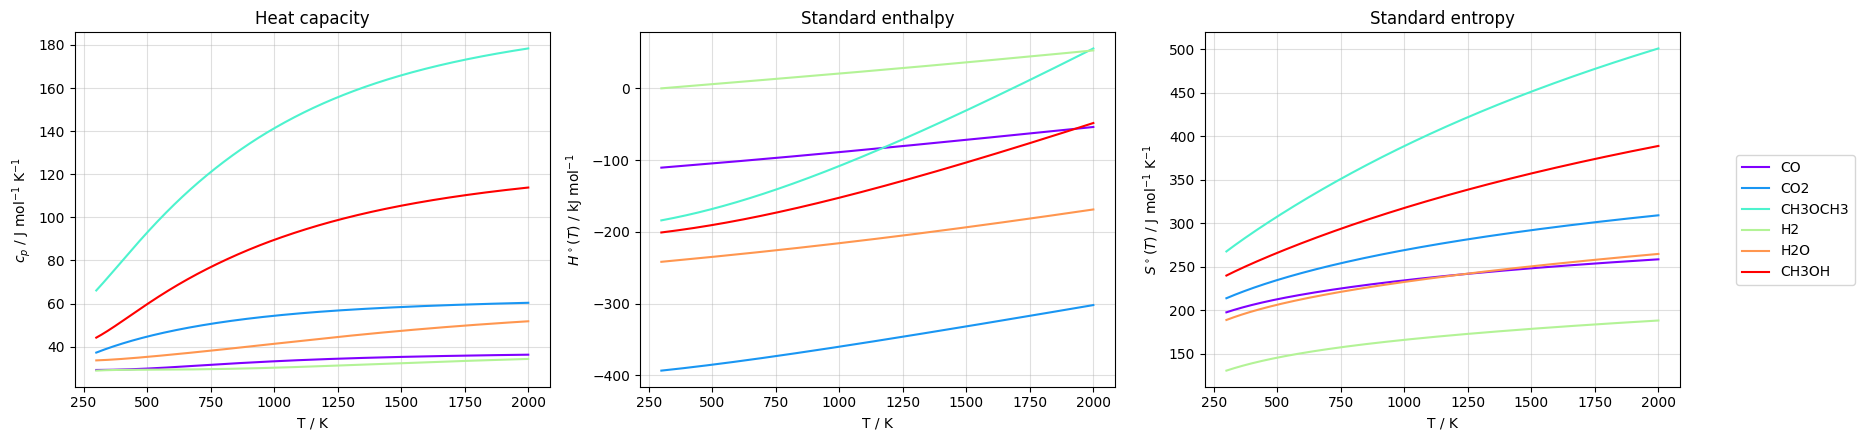

In [7]:
# Temperature range
T_range = np.linspace(300, 2000, 1000)  # # K, adjust validity range if necessary
species_list = ['CO', 'CO2', 'CH3OCH3', 'H2', 'H2O', 'CH3OH']

# # Collect data
cp_data = np.full((len(species_list), len(T_range)), np.nan)
hf_data = np.full((len(species_list), len(T_range)), np.nan)
s_data  = np.full((len(species_list), len(T_range)), np.nan)

for i, sp in enumerate(species_list):
    for j, T in enumerate(T_range):
        try:
            cp_data[i, j] = cp_T(sp, T)
            hf_data[i, j] = hf_T(sp, T)
            s_data[i, j]  = s_T(sp, T)
        except ValueError:
            pass  # T outside of NASA range → NaN remains

# Plot: 1×3 Layout
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# # Colors from rainbow colormap
colors = plt.cm.rainbow(np.linspace(0, 1, len(species_list)))

for i, sp in enumerate(species_list):
    axes[0].plot(T_range, cp_data[i],        label=sp, color=colors[i])
    axes[1].plot(T_range, hf_data[i] / 1000, label=sp, color=colors[i])  # → kJ/mol
    axes[2].plot(T_range, s_data[i],         label=sp, color=colors[i])

axes[0].set_xlabel('T / K')
axes[0].set_ylabel(r'$c_p$ / J mol$^{-1}$ K$^{-1}$')
axes[0].set_title('Heat capacity')

axes[1].set_xlabel('T / K')
axes[1].set_ylabel(r'$H^\circ(T)$ / kJ mol$^{-1}$')
axes[1].set_title('Standard enthalpy')

axes[2].set_xlabel('T / K')
axes[2].set_ylabel(r'$S^\circ(T)$ / J mol$^{-1}$ K$^{-1}$')
axes[2].set_title('Standard entropy')

for ax in axes:
    ax.grid(True, alpha=0.4)

# Single legend to the right of the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

The plotted thermodynamic profiles reveal two critical physical insights regarding the modeled system. First, all curves exhibit smooth and continuous transitions, which confirms that the automated switching between the low-temperature and high-temperature NASA polynomial intervals is functioning correctly. No non-physical discontinuities or integration jumps are observed. Second, across the entire temperature range, dimethyl ether (DME) consistently shows the highest heat capacity and entropy values. This behavior is consistent with molecular thermodynamics. As the largest and most complex species in the system, DME possesses a greater number of internal degrees of freedom, including vibrational and rotational modes, compared to the smaller components. As a result, it can store more thermal energy and exhibits a larger number of accessible microstates.

The graphs follow the basic laws of thermodynamics, which confirms that the parameters can be used to calculate the equilibrium constants.

## 4.4. Calculating Reaction Enthalpy, Entropy, and Gibbs Free Energy
Building on the properties of individual species, the overall thermodynamic properties of the reaction network are calculated by summing the enthalpy and entropy contributions from each species based on their stoichiometric coefficients. This procedure yields the standard reaction enthalpy ($\Delta_R H^\circ$) and reaction entropy ($\Delta_R S^\circ$). From these values, the standard Gibbs free energy of reaction ($\Delta_R G^\circ$) is determined, which is then used to calculate the thermodynamic equilibrium constant ($K^°$). The model also includes pressure effects by computing the mole fraction based equilibrium constant ($K_x$), using the total change in moles ($\Delta \nu = \sum \nu_i$).

\begin{equation}
  \Delta_R H(T) = \sum_i \nu_i H_i^\circ(T)
  \tag{11}
\end{equation}

\begin{equation}
  \Delta_R S(T) = \sum_i \nu_i S_i^\circ(T)
  \tag{12}
\end{equation}

\begin{align}
  \Delta_RG(T) &= \Delta_RH(T)-T\,\Delta_RS(T)
  \tag{13}
\end{align}

\begin{equation}
  K^°(T) =\exp\left(-\frac{\Delta_RG(T)}{R\,T}\right)
  \tag{14}
\end{equation}

\begin{equation}
K_x(T,p) = K^\circ(T) \left(\frac{p^\circ}{p}\right)^{\sum \nu_i}
\tag{15}
\end{equation}

* **$T$**: Absolute operating temperature, measured in Kelvin (K).
* **$\Delta_R H$**: Standard reaction enthalpy, measured in kilojoules per mole (kJ/mol).
* **$\Delta_R S$**: Standard reaction entropy, measured in joules per mole-kelvin (J/(mol·K)).
* **$\Delta_R G$**: Standard Gibbs free energy of reaction, measured in kilojoules per mole (kJ/mol).
* **$K^\circ$**: Thermodynamic equilibrium constant (dimensionless).
* **$K_x$**: Mole-fraction-based equilibrium constant, evaluated at a specific system pressure (e.g. $p = 1 \text{ bar}$).

In [8]:
def reaction_enthalpy(reaction, T):
    """
    Calculate the reaction enthalpy (ΔH) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔH: Reaction enthalpy in J/mol (float).
    """
    delta_H = 0.0
    for species, coeff in reaction:
        hf = hf_T(species, T)
        delta_H += coeff * hf
    return delta_H

def reaction_entropy(reaction, T):
    """
    Calculate the reaction entropy (ΔS) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔS: Reaction entropy in J/(mol*K) (float).
    """
    delta_S = 0.0
    for species, coeff in reaction:
        S = s_T(species, T)
        delta_S += coeff * S
    return delta_S

def reaction_gibbs_free_energy(reaction, T):
    """
    Calculate the reaction Gibbs free energy (ΔG) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - ΔG: Reaction Gibbs free energy in J/mol (float).
    """
    delta_H = reaction_enthalpy(reaction, T)
    delta_S = reaction_entropy(reaction, T)
    delta_G = delta_H - T * delta_S
    return delta_G

def eq_const_p(reaction, T):
    """
    Calculate the equilibrium constant (K) at a given temperature T for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    
    Returns:
    - K: Equilibrium constant (dimensionless).
    """
    delta_G = reaction_gibbs_free_energy(reaction, T)
    K = np.exp((-delta_G )/ (R * T))
    return K

# K_x = K_p * (p° / p)^Δν  with p° = 1 bar  →  K_x = K_p * p^(-Δν)

def stoich_coeff_change(reaction):
    """Change in molar stoichiometric coefficient Δν = Σ vi."""
    dnu = 0
    for species, coeff in reaction:
        dnu += coeff
    return dnu

def eq_const_x(reaction, T, p):
    """
    Calculate the equilibrium constant (K_x) at a given temperature T and pressure p for a specified reaction.
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - T: Temperature in Kelvin (float).
    - p: Pressure in bar (float).
    
    Returns:
    - K_x: Equilibrium constant (dimensionless).
    """
    K_p = eq_const_p(reaction, T)
    dnu = stoich_coeff_change(reaction)
    K_x = K_p * (p ** (-dnu))
    return K_x


print("\n--- Thermodynamic Properties Calculation ---")
# Validation values for Temperatures 298,15 K, 500 K, 1000 K, printed as a table for readability

print(f"{'Reaction':<10} {'T (K)':<10} {'ΔH (kJ/mol)':<20} {'ΔS (J/mol*K)':<20} {'ΔG (kJ/mol)':<20} {'K_p':<15} {'K_x (p=1 bar)':<20}")
reaction_names = ['R1', 'R2', 'R4', 'R3']  # Adjusted order for independence
for T in validation_temperatures:
    print("-" * 120)
    for i in range(4):
        r_reaction = reaction_tuples[i]
        r_name = reaction_names[i]
        delta_H = reaction_enthalpy(r_reaction, T) / 1000  # Convert to kJ/mol
        delta_S = reaction_entropy(r_reaction, T)
        delta_G = reaction_gibbs_free_energy(r_reaction, T) / 1000  # Convert to kJ/mol
        K_p = eq_const_p(r_reaction, T)
        K_x = eq_const_x(r_reaction, T, p=1)  # Assuming p=1 bar for K_x
        print(f"{r_name:<10} {T:<10.2f} {delta_H:<20.2f} {delta_S:<20.2f} {delta_G:<20.2f} {K_p:<15.2e} {K_x:<20.2e}")


--- Thermodynamic Properties Calculation ---
Reaction   T (K)      ΔH (kJ/mol)          ΔS (J/mol*K)         ΔG (kJ/mol)          K_p             K_x (p=1 bar)       
------------------------------------------------------------------------------------------------------------------------
R1         298.15     -49.25               -177.18              3.57                 2.37e-01        2.37e-01            
R2         298.15     -90.40               -219.20              -25.05               2.44e+04        2.44e+04            
R4         298.15     -24.05               -23.41               -17.08               9.81e+02        9.81e+02            
R3         298.15     41.15                42.02                28.62                9.68e-06        9.68e-06            
------------------------------------------------------------------------------------------------------------------------
R1         500.00     -57.86               -199.42              41.85                4.24e-05        4

The results are consistent with basic thermodynamic principles. The strongly exothermic and mole-reducing reactions $R_1$ and $R_2$ show a clear decrease in equilibrium constant at higher temperatures, because the entropic term becomes more dominant in the Gibbs free energy. In contrast, the reverse water-gas shift reaction ($R_3$) becomes more favorable as temperature increases, while the methanol dehydration to DME ($R_4$) shows only small changes in equilibrium behavior due to its relatively small entropy change.

The calculated reaction heats are in agreement with literature sources. Lawes et al. [8] give $\Delta_\mathrm{R}\mathrm{H}°$ for reactions 1 to 3, and Kansha et al. [9] give the standard reaction heat for the methanol dehydration ($\mathrm{R}_4$):

| Reaction | R1 | R2 | R3 | R4 |
|----------|--------|-------|------|------|
| $\Delta_\mathrm{R}\mathrm{H}$ / kJ $\mathrm{mol}^{-1}$ | -49.5 | -90.6 | 41.2 | -23.4 |

These values are reported for standard conditions. If we compare them with the values obtained from our calculations (at 1 bar and 298.15 K), they show high agreement. The slight deviations in our calculated results could be explained by rounding errors during the calculation, or by the fact that our values are obtained from mathematical expressions and fitted data from the NASA database. Either way, the agreement of our data with literature values is high enough for us to be confident in using these values for the calculation of the reaction extent and, by extension, the equilibrium yield.

### 4.5. Literature Reference Values for Equilibrium Constants

**For R1, R2, R3** 

The equilibrium constants presented are derived from the empirically fitted correlations provided in the referenced literature. Specifically, the constants for reactions $R_2$ and $R_3$ are obtained directly from the source’s analytical expressions, while the equilibrium constant for reaction $R_1$ is determined via the stoichiometric consistency relation $K_p^\circ(R_1) = K_p^\circ(R_2) \cdot K_p^\circ(R_3)$. It should be noted that the source material exclusively reports the thermodynamic equilibrium constants ($K_p^\circ$). Consequently, enthalpy ($\Delta_R H^\circ$), entropy ($\Delta_R S^\circ$), and Gibbs free energy ($\Delta_R G^\circ$) of reaction must be derived analytically [4].


| Reaction | T (°C) | T (K) | K_p° | Unit |
|----------|--------|-------|------|------|
| R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O | 200 | 473.15 | 7.66 × 10⁻⁵ | bar⁻² |
| R2: CO + 2H₂ ⇌ CH₃OH          | 200 | 473.15 | 1.77 × 10⁻²  | bar⁻² |
| R3: CO₂ + H₂ ⇌ CO + H₂O       | 200 | 473.15 | 4.33 × 10⁻³  | —     |
| R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O | 250 | 523.15 | 1.89 × 10⁻⁵ | bar⁻² |
| R2: CO + 2H₂ ⇌ CH₃OH          | 250 | 523.15 | 1.66 × 10⁻³  | bar⁻² |
| R3: CO₂ + H₂ ⇌ CO + H₂O       | 250 | 523.15 | 1.14 × 10⁻²  | —     |
| R2: CO + 2H₂ ⇌ CH₃OH          | 300 | 573.15 | 2.28 × 10⁻⁴  | bar⁻² |
| R1: CO₂ + 3H₂ ⇌ CH₃OH + H₂O | 300 | 573.15 | 5.72 × 10⁻⁶ | bar⁻² |
| R3: CO₂ + H₂ ⇌ CO + H₂O       | 300 | 573.15 | 2.51 × 10⁻²  | —     |

**For R4** 

> > **Note:** Temperature data points evaluated for reaction $R_4$ (498 K, 523 K, and 573 K) exhibit a slight deviation from the intervals applied to reactions $R_1$ through $R_3$ (473 K, 523 K, and 573 K). While the higher temperature conditions representing 250°C and 300°C are practically identical across both datasets with a negligible margin (Δ = 0.15 K), a distinct variance exists at the lowest temperature bound, which is evaluated here at 225°C compared to the 200°C baseline used previously [5].

| Reaction | T (°C) | T (K) | K_p° | ΔG°r (kJ mol⁻¹) | Unit |
|----------|--------|-------|------|-----------------|------|
| R4: 2 CH₃OH ⇌ DME + H₂O | 225 | 498 | 12.948 | −10.604 | — |
| R4: 2 CH₃OH ⇌ DME + H₂O | 250 | 523 | 10.810 | −10.351 | — |
| R4: 2 CH₃OH ⇌ DME + H₂O | 300 | 573 |  7.318 |  −9.482 | — |




An apparent numerical deviation can be observed when comparing our explicitly calculated equilibrium constants ($K^\circ$) with the literature values provided by Graaf & Winkelman (2016) [4]. This discrepancy does not originate from our mathematical implementation or the ideal gas assumption used in our exponential relation $K^\circ(T) = \exp(-\Delta_R G(T) / RT)$. By definition, the thermodynamic standard equilibrium constant $K^\circ$ is always referenced to the ideal gas state at 1 bar, regardless of the actual reactor pressure. Graaf's use of the SRK (Soave-Redlich-Kwong) equation of state was exclusively applied to correct experimental high-pressure measurements (via fugacity coefficients) back to this ideal standard state, not to alter the fundamental definition of $K^\circ$.

The root cause of the deviation lies entirely in the extreme sensitivity of the exponential function to minor variations in the standard thermodynamic baseline data. As explicitly stated in the referenced paper, shifting the standard Gibbs free energy of formation ($\Delta_f G^\circ$) for methanol by a mere 0.5% alters the resulting equilibrium constant by approximately 33%. While our computational model strictly relies on the unmodified NIST-JANAF thermochemical tables, Graaf & Winkelman deliberately refitted the standard formation energies of methanol and carbon monoxide to match their specific experimental high-pressure reactor data. Consequently, the observed variance is not a computational error, but rather an expected statistical offset arising from the utilization of different foundational thermodynamic databases.

### 4.6. Visualizing the Values for $\Delta_{R}H(T)$, $\Delta_{R}S(T)$ and $\Delta_{R}G(T)$

To comprehensively evaluate the thermodynamic behavior of the synthesis network over a wide operational spectrum, properties were evaluated continuously from 300 K to 2000 K. The resulting visualizations reflect the temperature dependence described by the Gibbs–Helmholtz relationship.

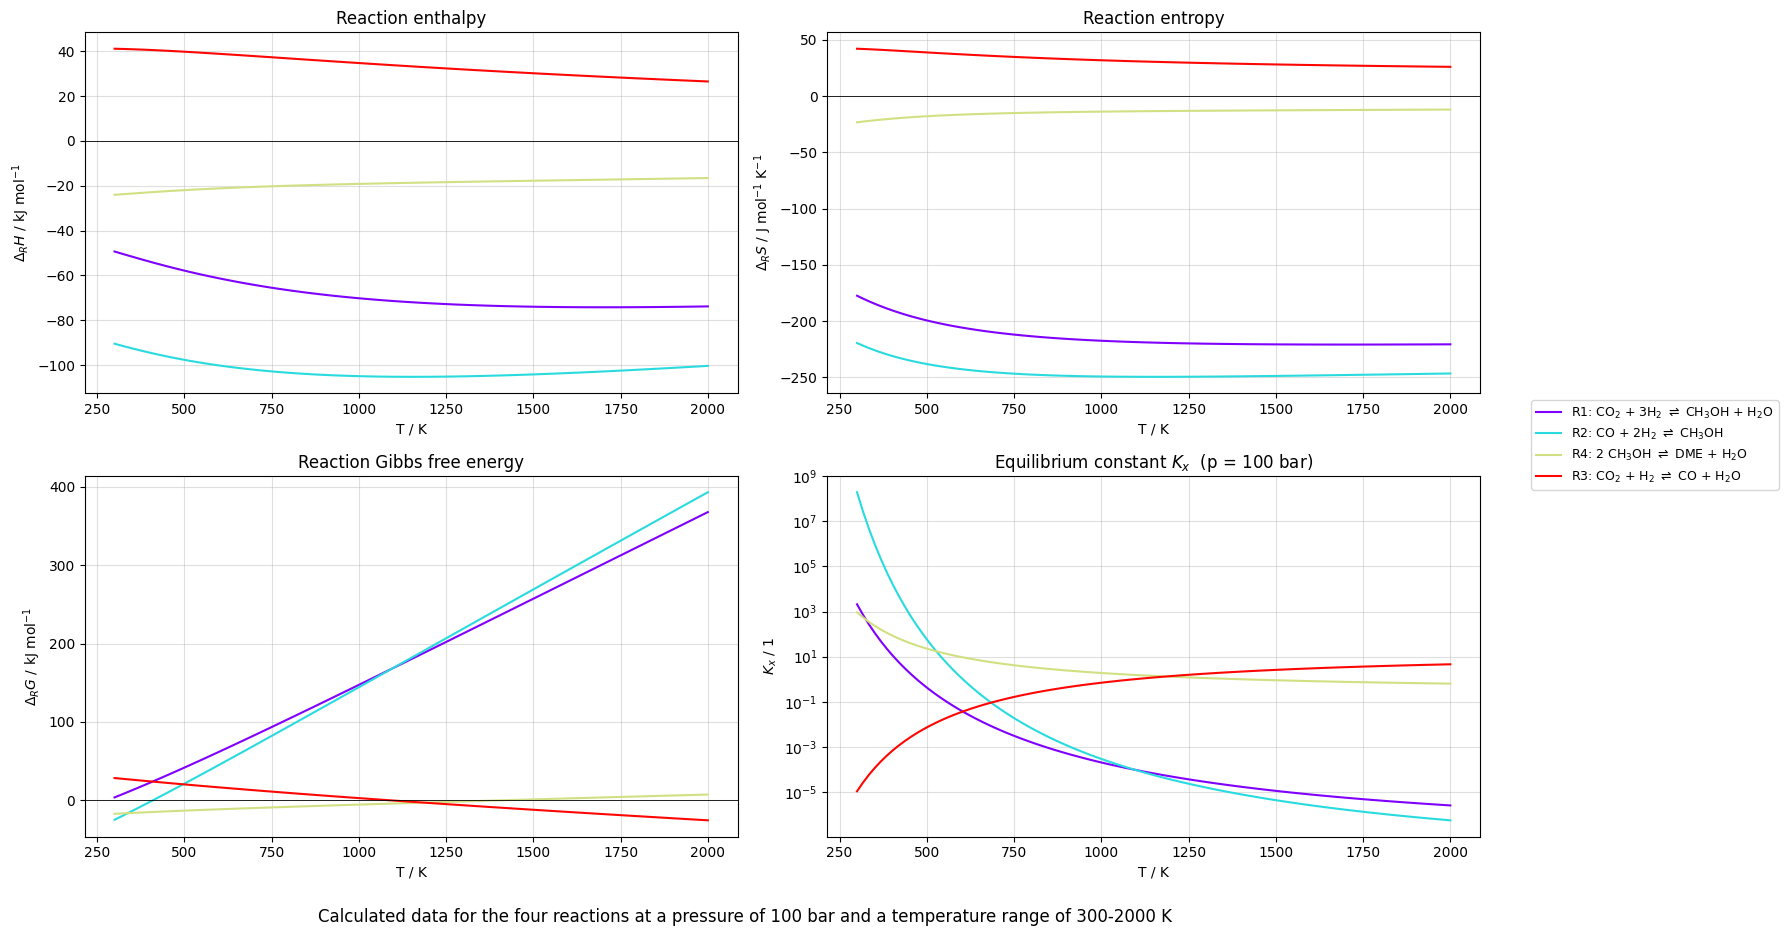

In [9]:
T_range = np.linspace(300, 2000, 100)

reaction_labels = [
    r'R1: CO$_2$ + 3H$_2$ $\rightleftharpoons$ CH$_3$OH + H$_2$O',
    r'R2: CO + 2H$_2$ $\rightleftharpoons$ CH$_3$OH',
    r'R4: 2 CH$_3$OH $\rightleftharpoons$ DME + H$_2$O',
    r'R3: CO$_2$ + H$_2$ $\rightleftharpoons$ CO + H$_2$O',
]

p_ref = 100  # bar — reference pressure for K_x calculation, can be adjusted as needed

# --- calculating data ---
dH_data = np.full((4, len(T_range)), np.nan)
dS_data = np.full((4, len(T_range)), np.nan)
dG_data = np.full((4, len(T_range)), np.nan)
Kx_data = np.full((4, len(T_range)), np.nan)

for r_idx in range(4):
    for j, T in enumerate(T_range):
        try:
            dH_data[r_idx, j] = reaction_enthalpy(reaction_tuples[r_idx], T)
            dS_data[r_idx, j] = reaction_entropy(reaction_tuples[r_idx], T)
            dG_data[r_idx, j] = reaction_gibbs_free_energy(reaction_tuples[r_idx], T)
            Kx_data[r_idx, j] = eq_const_x(reaction_tuples[r_idx], T, p_ref)
        except ValueError:
            pass

# --- 2×2 Plot with shared legend ---
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()  # [ΔH, ΔS, ΔG, K_x]

# defining colors for consistent legend, using rainbow colormap with 4 distinct colors for the 4 reactions
colors = plt.cm.rainbow(np.linspace(0, 0.99, 4))

for r_idx in range(4):
    axes[0].plot(T_range, dH_data[r_idx] / 1000, label=reaction_labels[r_idx], color=colors[r_idx])
    axes[1].plot(T_range, dS_data[r_idx],         label=reaction_labels[r_idx], color=colors[r_idx])
    axes[2].plot(T_range, dG_data[r_idx] / 1000,  label=reaction_labels[r_idx], color=colors[r_idx])
    axes[3].plot(T_range, Kx_data[r_idx],          label=reaction_labels[r_idx], color=colors[r_idx])

axes[0].set_ylabel(r'$\Delta_R H$ / kJ mol$^{-1}$')
axes[0].set_title('Reaction enthalpy')

axes[1].set_ylabel(r'$\Delta_R S$ / J mol$^{-1}$ K$^{-1}$')
axes[1].set_title('Reaction entropy')

axes[2].set_ylabel(r'$\Delta_R G$ / kJ mol$^{-1}$')
axes[2].set_title('Reaction Gibbs free energy')

axes[3].set_ylabel(r'$K_x$ / 1')
axes[3].set_title(f'Equilibrium constant $K_x$  (p = {p_ref} bar)')
axes[3].set_yscale('log')  # log-scale because of order of magnitude (R2 >> R3)

for ax in axes:
    ax.set_xlabel('T / K')
    ax.grid(True, alpha=0.4, which='both')
    ax.axhline(0, color='k', lw=0.6)

# single legend to the right of the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=True)
fig.text(0.5, -0.03, f'Calculated data for the four reactions at a pressure of {p_ref} bar and a temperature range of 300-2000 K', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

The graphs show that the reaction enthalpies ($\Delta_R H$) and entropies ($\Delta_R S$) exhibit only mild temperature dependencies, aligning closely with the expected behavior from the specific heat capacities. However, the standard Gibbs free energy ($\Delta_R G$) demonstrates a strong linear divergence due to the increasingly dominant $-T\Delta_R S$ term. The zero-crossing points in the $\Delta_R G$ profile explicitly identify the thermodynamic reversal temperatures, illustrating where the entropically unfavorable methanol synthesis reactions ($R_1$ and $R_2$) transition from spontaneous to non-spontaneous.

It is important to note that the values plotted above are calculated for the standard pressure of 1 bar. For higher pressures, the calculation of the Gibbs free energy needs to be extended. Assuming ideal gas conditions, we can write the mole-fraction equilibrium constant as in Equation 16. From this pressure-corrected equilibrium constant, we can calculate a new, pressure-corrected Gibbs free energy for the reactions, as in Equation 17.

\begin{equation}
K_x(T,p) = K^\circ(T) \left( \frac{p^\circ}{p} \right)^{\Sigma \nu}
\tag{16}
\end{equation}

\begin{equation}
\Delta_R G(T,p) = -RT \ln\left(K_x(T,p)\right)
\tag{17}
\end{equation}

These pressure-corrected values are visualized below.

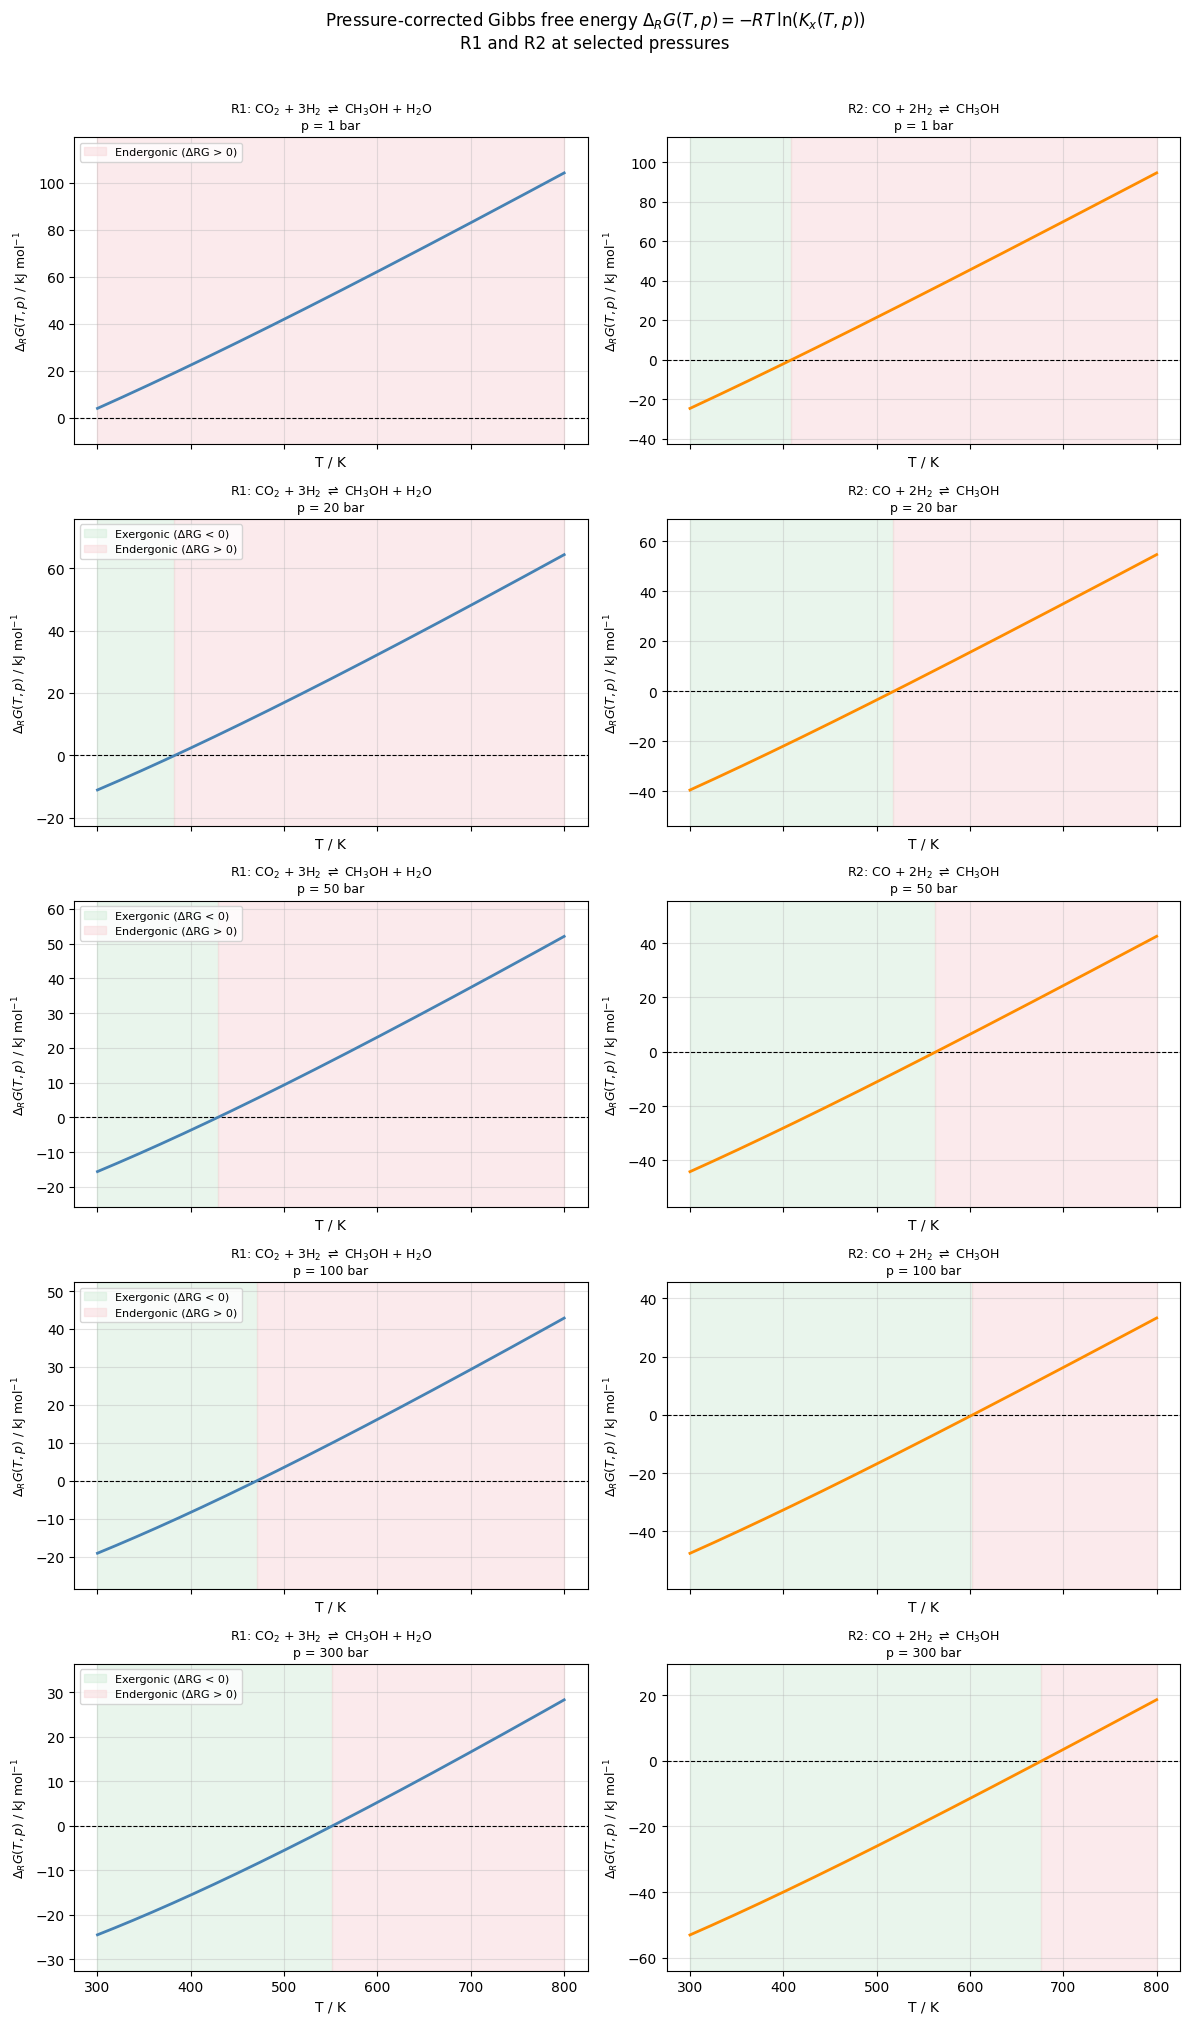

In [16]:
# =============================================================================
# Pressure-corrected Gibbs Free Energy: ΔRG(T, p) = -RT * ln(K_x(T, p))
# 
# Background:
#   The standard Gibbs free energy ΔRG°(T) is calculated at p° = 1 bar.
#   For real operating pressures, K_x(T, p) already incorporates the pressure
#   correction via:  K_x = K_p * (p°/p)^Δν
#   Inverting this relation gives the pressure-corrected Gibbs free energy:
#       ΔRG(T, p) = -RT * ln(K_x(T, p))
#   This equals ΔRG°(T) only at p = 1 bar; at other pressures it reflects
#   the true thermodynamic driving force under process conditions.
#
# Reaction index convention in reaction_tuples:
#   Index 0 → R1: CO2 + 3H2  ⇌ CH3OH + H2O
#   Index 1 → R2: CO  + 2H2  ⇌ CH3OH
#   Index 2 → R4: 2 CH3OH    ⇌ DME + H2O   (not shown here)
#   Index 3 → R3: CO2 + H2   ⇌ CO + H2O    (not shown here)
# =============================================================================

# --- Parameters ---
T_range_vis  = np.linspace(300, 800, 300)      # Temperature range of interest [K]
pressures    = [1, 20, 50, 100, 300]                # Pressures to evaluate [bar]
rxn_indices  = [0, 1]                          # R1 (index 0) and R2 (index 1)
rxn_labels   = [
    r'R1: CO$_2$ + 3H$_2$ $\rightleftharpoons$ CH$_3$OH + H$_2$O',
    r'R2: CO + 2H$_2$ $\rightleftharpoons$ CH$_3$OH',
]

# --- Pre-compute ΔRG(T, p) for each reaction and each pressure ---
# Shape of dRG_data: (n_reactions, n_pressures, n_temperatures)
dRG_data = np.full((len(rxn_indices), len(pressures), len(T_range_vis)), np.nan)

for ri, r_idx in enumerate(rxn_indices):
    for pi, p in enumerate(pressures):
        for ti, T in enumerate(T_range_vis):
            try:
                # Retrieve the pressure-corrected mole-fraction equilibrium constant.
                # K_x = K_p * (p° / p)^Δν, where p° = 1 bar is implicit in eq_const_x().
                K_x = eq_const_x(reaction_tuples[r_idx], T, p)

                # Guard against non-positive K_x values (unphysical; would cause log errors).
                if K_x > 0:
                    # Invert the equilibrium constant definition to obtain ΔRG(T, p).
                    # Units: J/mol → convert to kJ/mol for readability.
                    dRG_data[ri, pi, ti] = -R * T * np.log(K_x) / 1000
            except ValueError:
                # Temperature outside valid NASA-Glenn range for this species → leave as NaN.
                pass

# --- Plotting ---
# Layout: one row per pressure (5 total), each with 2 subplots side by side (R1 | R2).
# The exergonic region (ΔRG < 0, reaction thermodynamically favored) is shaded green.
# The endergonic region (ΔRG > 0, reaction not favored)               is shaded red.

fig, axes = plt.subplots(
    nrows=len(pressures), ncols=len(rxn_indices),
    figsize=(12, 4 * len(pressures)),
    sharex=True
)

# Fixed colors per reaction, consistent across all pressure subplots
rxn_colors = ['steelblue', 'darkorange']

for pi, p in enumerate(pressures):
    for ri, r_idx in enumerate(rxn_indices):
        ax = axes[pi, ri]
        dRG = dRG_data[ri, pi, :]

        # Find the zero-crossing temperature (transition point exergonic ↔ endergonic)
        # np.interp requires a monotonic x-axis, so we search for sign changes manually.
        sign_changes = np.where(np.diff(np.sign(dRG)))[0]

        if len(sign_changes) > 0:
            # Take the first zero crossing as the transition temperature
            T_cross = T_range_vis[sign_changes[0]]
            # Exergonic region: T < T_cross → shade the full vertical extent
            ax.axvspan(T_range_vis[0], T_cross, color='#d4edda', alpha=0.5, zorder=0, label='Exergonic (ΔRG < 0)')
            # Endergonic region: T > T_cross → shade the full vertical extent
            ax.axvspan(T_cross, T_range_vis[-1], color='#f8d7da', alpha=0.5, zorder=0, label='Endergonic (ΔRG > 0)')
        else:
            # No crossing found: shade the entire plot in whichever region applies
            color = '#d4edda' if np.nanmean(dRG) < 0 else '#f8d7da'
            label = 'Exergonic (ΔRG < 0)' if np.nanmean(dRG) < 0 else 'Endergonic (ΔRG > 0)'
            ax.axvspan(T_range_vis[0], T_range_vis[-1], color=color, alpha=0.5, zorder=0, label=label)

        # --- Zero line for visual reference ---
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', zorder=2)

        # --- Main curve ---
        ax.plot(T_range_vis, dRG, color=rxn_colors[ri], linewidth=2.0, zorder=3)

        # --- Axis limits: clip y to a physically meaningful window ---
        # (avoids extreme values at low T distorting the view)
        finite_vals = dRG[np.isfinite(dRG)]
        if len(finite_vals) > 0:
            y_margin = 0.15 * (np.nanmax(finite_vals) - np.nanmin(finite_vals) + 1)
            ax.set_ylim(np.nanmin(finite_vals) - y_margin, np.nanmax(finite_vals) + y_margin)

        # --- Labels ---
        ax.set_xlabel('T / K', fontsize=10)
        ax.set_ylabel(r'$\Delta_R G(T,p)$ / kJ mol$^{-1}$', fontsize=9)
        ax.set_title(f'{rxn_labels[ri]}\np = {p} bar', fontsize=9)
        ax.grid(True, alpha=0.35)

        # --- Legend only in the first subplot of each row ---
        if ri == 0:
            ax.legend(fontsize=8, loc='upper left')

fig.suptitle(
    r'Pressure-corrected Gibbs free energy $\Delta_R G(T,p) = -RT\,\ln(K_x(T,p))$'
    '\nR1 and R2 at selected pressures',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.show()

The plots above show that the pressure-corrected Gibbs free energy of reactions 1 and 2 becomes more favorable at increased pressures. At high pressures, the reactions become more exergonic at low temperatures, enabling them to proceed spontaneously. This pressure dependence is a direct consequence of Le Chatelier's principle: both R1 ($\Delta\nu = -2$) and R2 ($\Delta\nu = -2$) proceed with a significant reduction in the total number of moles. An increase in pressure therefore shifts the equilibrium strongly towards the products, which is reflected in the increasingly negative $\Delta_R G(T,p)$ at elevated pressures.

For the DME yield to be calculated later, this should result in a higher yield at high pressures and low temperatures. This is because for the formation of DME through methanol dehydration, methanol must be present in the reactor. When using a feed of purely $\mathrm{CO}$, $\mathrm{CO}_2$ and $\mathrm{H}_2$, reactions R1 or R2 need to take place for any DME to be formed. At temperatures above the respective zero-crossing, both reactions become endergonic, meaning the equilibrium lies strongly on the reactant side. As visible in the plots, increasing the pressure from 1 bar to 300 bar shifts this transition temperature by approximately 250 K for R1 and approximately 268 K for R2, significantly expanding the operable temperature window for spontaneous methanol synthesis. Since no significant amount of methanol is formed above these transition temperatures, the DME yield is expected to approach zero, even though the dehydration reaction R4 itself remains thermodynamically favorable throughout.

To calculate the reaction extent later, we use the equilibrium constant $K_x$. The pressure dependency of that constant is shown in the plot below:

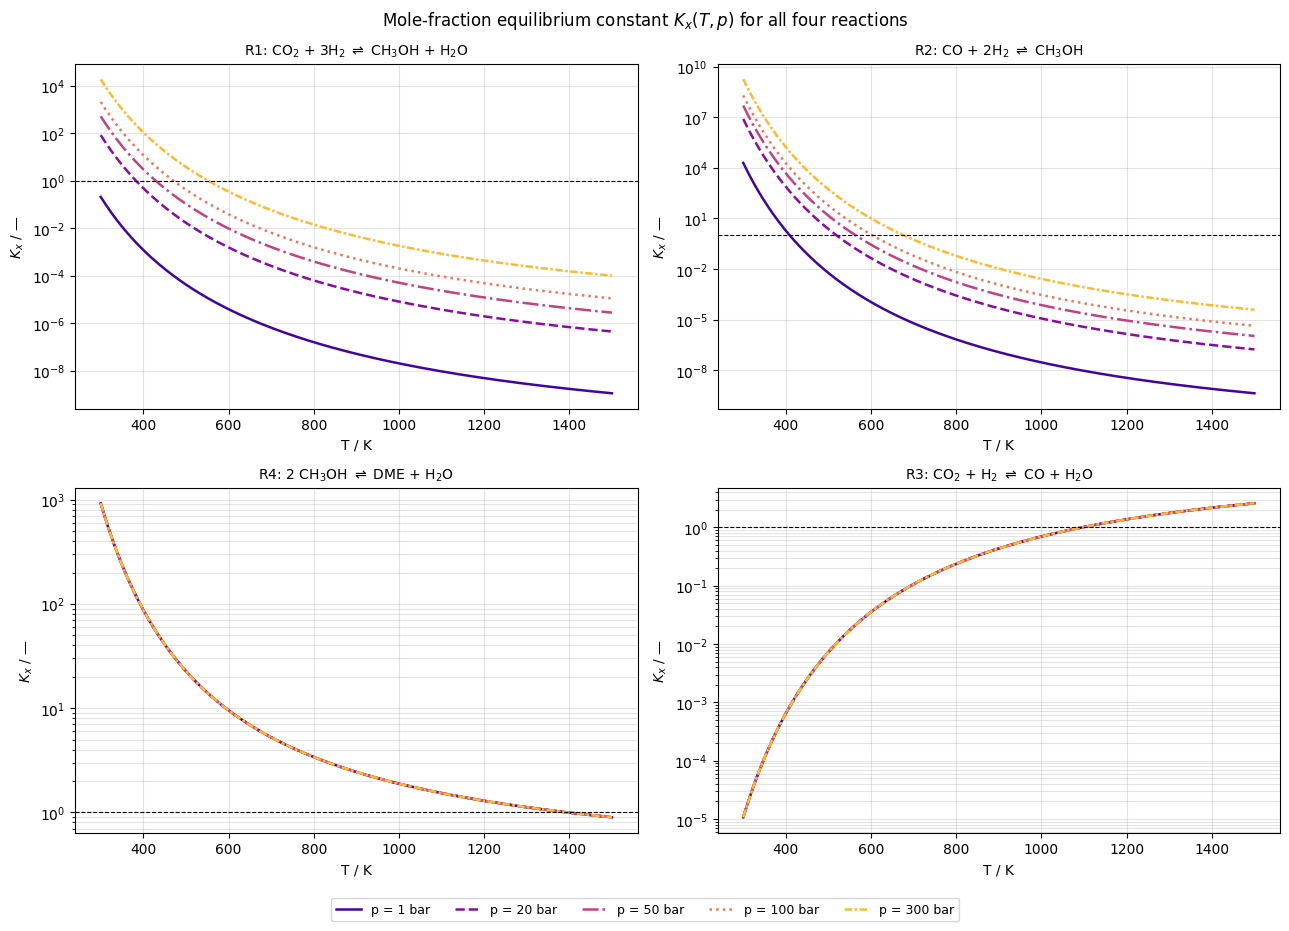

In [11]:
# =============================================================================
# K_x(T, p) for all four reactions at selected pressures
#
# K_x is the mole-fraction based equilibrium constant, which incorporates the
# pressure correction via: K_x = K_p * (p° / p)^Δν  (p° = 1 bar implicit)
# A higher K_x indicates a stronger thermodynamic driving force toward products.
# Plotted on a logarithmic y-axis due to the large range of magnitudes.
#
# Reaction index convention in reaction_tuples:
#   Index 0 → R1: CO2 + 3H2  ⇌ CH3OH + H2O   (Δν = -3)
#   Index 1 → R2: CO  + 2H2  ⇌ CH3OH          (Δν = -2)
#   Index 2 → R4: 2 CH3OH    ⇌ DME + H2O      (Δν =  0)
#   Index 3 → R3: CO2 + H2   ⇌ CO + H2O       (Δν =  0)
# =============================================================================

# --- Parameters ---
T_range_kx   = np.linspace(300, 1500, 300)       # Temperature range [K]
pressures_kx = [1, 20, 50, 100, 300]            # Pressures to evaluate [bar]
all_rxn_indices = [0, 1, 2, 3]                  # All four reactions
all_rxn_labels  = [
    r'R1: CO$_2$ + 3H$_2$ $\rightleftharpoons$ CH$_3$OH + H$_2$O',
    r'R2: CO + 2H$_2$ $\rightleftharpoons$ CH$_3$OH',
    r'R4: 2 CH$_3$OH $\rightleftharpoons$ DME + H$_2$O',
    r'R3: CO$_2$ + H$_2$ $\rightleftharpoons$ CO + H$_2$O',
]

# Use a perceptually uniform colormap to distinguish pressure levels
pressure_colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(pressures_kx)))
pressure_linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]  # solid, dashed, dashdot, dotted, densely dashdotted

# --- Pre-compute K_x(T, p) for all reactions and pressures ---
# Shape: (n_reactions, n_pressures, n_temperatures)
Kx_all = np.full((len(all_rxn_indices), len(pressures_kx), len(T_range_kx)), np.nan)

for ri, r_idx in enumerate(all_rxn_indices):
    for pi, p in enumerate(pressures_kx):
        for ti, T in enumerate(T_range_kx):
            try:
                Kx_all[ri, pi, ti] = eq_const_x(reaction_tuples[r_idx], T, p)
            except ValueError:
                # Temperature outside valid NASA-Glenn range → leave as NaN
                pass

# --- Plotting: 2x2 grid, one subplot per reaction ---
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()  # Index order: R1, R2, R4, R3

for ri, r_idx in enumerate(all_rxn_indices):
    ax = axes[ri]

    for pi, p in enumerate(pressures_kx):
        ax.plot(
            T_range_kx,
            Kx_all[ri, pi, :],
            color=pressure_colors[pi],
            linestyle=pressure_linestyles[pi],
            linewidth=1.8,
            label=f'p = {p} bar'
        )

    # Reference line at K_x = 1: equilibrium point where products = reactants
    ax.axhline(1, color='black', linewidth=0.8, linestyle='--', zorder=2)

    ax.set_yscale('log')
    ax.set_xlabel('T / K', fontsize=10)
    ax.set_ylabel(r'$K_x$ / —', fontsize=10)
    ax.set_title(all_rxn_labels[ri], fontsize=10)
    ax.grid(True, alpha=0.35, which='both')

# --- Shared legend below the plots ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    ncol=len(pressures_kx),
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, -0.04)
)

fig.suptitle(
    r'Mole-fraction equilibrium constant $K_x(T,p)$ for all four reactions',
    fontsize=12
)
plt.tight_layout()
plt.show()

We can observe that the equilibrium constant $K_x$ shows a pressure dependency for reactions R1 and R2, while remaining unchanged for reactions R3 and R4. This is because R1 and R2 have a non-zero total stoichiometric change ($\Delta\nu = -2$ for both), while R3 and R4 do not change the total number of moles ($\Delta\nu = 0$). Using the definition of $K_x$ given in Equation 16, $K_x$ reduces to $K^\circ$ for $\Delta\nu = 0$, making these two reactions pressure-independent.

## 5. Determination of the Reaction Extents ($\xi$) from Equilibrium Constants ($K_x$)

In the preceding sections, the mole fraction-based equilibrium constant, $K_x$, was calculated. For a single independent reaction, this constant is fundamentally defined as:

\begin{align}
    K_x &= \prod_i x_i^{\nu_i}
    \tag{18}
\end{align}

The primary objective is to compute the extent of reaction, $\xi_j$, for the three independent key reactions $j \in \{R_1, R_2, R_4\}$. To achieve this, the molar balance for each component must be established. The steady-state molar flow rate of component $i$ exiting a multiple-reaction network is formulated as:


\begin{align}
    \dot{n_{i,out}} &= \dot{n_{i,in}} + \sum_{j=1}^N \nu_{i,j} \cdot \xi_{j}
    \tag{19}
\end{align}

Consequently, the total effluent molar flow rate of the mixture is the sum of all individual component flows:

\begin{align}
    \dot{n_{out}} &= \dot{n_{in}} + \sum_{j=1}^N \xi_{j} \cdot (\sum_i^M \nu_{j, i})
    \tag{20}
\end{align}

Utilizing these mass balance formulations, the molar fraction of any species $i$ at the outlet ($x_{i,out}$) can be expressed explicitly as a function of the reaction extents:

\begin{align}
  x_{i,out} &= \frac{\dot n_{i,out}}{\dot n_{out}}=\frac{\dot{n_{i,in}} + \sum_{j=1}^N \nu_{i,j} \cdot \xi_{j}}{\dot{n_{in}} + \sum_{j=1}^N \xi_{j} \cdot (\sum_i^M \nu_{j, i})}
  \tag{21}
\end{align}

By substituting this mole fraction definition into the equilibrium constant expression, a system of nonlinear equations is constructed. Providing an initial guess for the reaction extents ($\xi$), the numerical solution is obtained by iteratively finding the roots of the following objective function for the designated key reactions:

\begin{align}
    K_{x,j} - \prod_i x_{i}^{\nu_{i,j}} = 0
    \tag{22}
\end{align}

Successfully minimizing this residual function yields a numerical solution for the reaction extents ($\xi$).

* **$K_{x,j}$**: Mole fraction-based equilibrium constant for reaction $j$.
* **$x_{i}$ / $x_{i,out}$**: Mole fraction of species $i$.
* **$\nu_{i,j}$**: Stoichiometric coefficient of species $i$ in reaction $j$ (assigned negative values for reactants and positive values for products).
* **$\xi_j$**: Extent of reaction for reaction $j$ (indicates the progression of the reaction).
* **$\dot{n}_{i,in}$ / $\dot{n}_{i,out}$**: Inlet and outlet molar flow rates of component $i$.
* **$\dot{n}_{in}$ / $\dot{n}_{out}$**: Total inlet and outlet molar flow rates of the entire mixture.
* **$N$**: Total number of independent reactions in the network.
* **$M$**: Total number of chemical species involved in the system.


In [ ]:
from scipy.optimize import root

def material_balance(reaction, xi, n_in, rc_ind):
    """
    Calculate the material balance for a given reaction, extent of reaction (xi), and initial moles (n_in).
    
    Parameters:
    - reaction: A list of tuples representing the reaction. Each tuple contains (species, coefficient).
                Coefficients should be negative for reactants and positive for products.
    - xi: Extent of reactions (array of floats).
    - n_in: Initial moles of each species as an array [mol/h].
    - rc_ind: Indexes of the reactions for which to solve. (array of ints)
    
    Returns:
    - n_out: Final moles of each species after the reaction as an array [mol/h].
    """
    n_out = n_in.copy()                                     # Start with initial moles
    for i in range(min(len(rc_ind), len(reaction))):        # Loop through the reactions up to the specified index
        for j in range(len(n_in)):                          # Calculate the change in moles for each species based on the reaction coefficients and extent of reaction
            species, coeff = reaction[rc_ind[i]][j]
            n_out[j] = n_out[j] + (coeff * xi[i])           # Update the moles based on the extent of reaction and the stoichiometric coefficients
    return n_out                                            # Return the final moles after the reaction for the solver to compare and refine the guess of xi

def mole_fraction(n_out):
    """
    Calculate the mole fraction of each species given the final moles.
    
    Parameters:
    - n_out: Final moles of each species as an array [mol/h].
    
    Returns:
    - x: Mole fraction of each species as an array.
    """
    total_moles = np.sum(n_out)
    if total_moles == 0:
        return np.zeros_like(n_out)  # Avoid division by zero
    x = n_out / total_moles
    return x

def equilibrium_residuals(xi, reaction_list, n_in, T, p, reac_index):
    """
    Residuals of the equilibrium conditions in direct (non-log) form:
    res_k = K_x * prod(x_educt^|nu|) - prod(x_prod^nu) = 0
    
    Parameters
    ----------
    xi           : array, shape (n_reactions,)
    reaction_list: list of reactions in tuple form
    n_in         : array, shape (n_species,)
    T            : float - temperature [K]
    p            : float - pressure [bar]
    reac_index   : list of int
    
    Returns
    -------
    res : array, shape (n_reactions,)
    """
    n_out = material_balance(reaction_list, xi, n_in, reac_index)
    total = np.sum(n_out)
    x = np.clip(n_out / total, 1e-12, 1.0)

    res = np.zeros(len(reac_index))
    for k, j in enumerate(reac_index):
        K_x = eq_const_x(reaction_list[j], T, p)
        educt_term   = 1.0
        product_term = 1.0
        for i, (species, coeff) in enumerate(reaction_list[j]):
            if coeff < 0:
                educt_term   *= x[i] ** abs(coeff)
            elif coeff > 0:
                product_term *= x[i] ** coeff
        res[k] = K_x * educt_term - product_term

    return res

#--- Calculating a meaningful starting guess from the given starting conditions, to help the solver start ---
def make_initial_guess(n_in, reac_index, reaction_list, fraction=0.01):
    """
    Generate a physically motivated initial guess for xi based on the limiting
    reactant of each reaction. Uses a small fraction of the limiting reactant
    to ensure all species are nonzero at the start.
    
    Parameters
    ----------
    n_in         : array - inlet molar flow [mol/h]
    reac_index   : list of int - reaction indices to solve
    reaction_list: list of reactions in tuple form
    fraction     : float - fraction of limiting reactant to use as guess
    
    Returns
    -------
    xi_init : array, shape (n_reactions,)
    """
    xi_init = np.zeros(len(reac_index))
    for k, j in enumerate(reac_index):
        limiting = np.inf
        for i, (species, coeff) in enumerate(reaction_list[j]):
            if coeff < 0:  # reactant
                available = n_in[i] / abs(coeff)
                if available > 0:
                    limiting = min(limiting, available)
        if np.isinf(limiting):
            limiting = 0.01  # fallback if no reactant present
        xi_init[k] = max(fraction * limiting, 1e-6)  # ensure non-zero start
    return xi_init


def root_solver(reaction_list, xi_init, n_in, T, p, reac_index):
    """
    Solves for equilibrium xi using scipy.optimize.root (method: hybr).

    Parameters
    ----------
    reaction_list: list of reactions in tuple form
    xi_init      : array - primary initial guess for xi [mol/h]
    n_in         : array - inlet molar flow [mol/h]
    T            : float - temperature [K]
    p            : float - pressure [bar]
    reac_index   : list of int - indices of reactions to solve

    Returns
    -------
    xi  : array  - equilibrium extent of reaction
    sol : OptimizeResult - full solver result
    """
    if xi_init is None:
        xi_init = make_initial_guess(n_in, reac_index, reaction_list)

    sol = root(
        equilibrium_residuals,
        xi_init,
        args=(reaction_list, n_in, T, p, reac_index),
        method='hybr',
        tol=1e-8
    )
    return sol.x, sol


for k, n_in_test in enumerate([
    np.array([1.0, 1.0, 0.0, 2.0, 0.0, 0.0]),
    np.array([2.0, 1.0, 1.0, 0.0, 2.0, 1.0]),
    np.array([0.0, 0.0, 0.0, 2.0, 1.0, 2.0]),
    np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0]),
    np.array([2.0, 1.0, 0.0, 1.0, 0.0, 0.0]),
]):
    xi, sol = root_solver(reaction_tuples, None, n_in_test, 500, 1, [0, 1, 2])
    n_out = material_balance(reaction_tuples, xi, n_in_test, [0, 1, 2])
    print(f"Test {k+1}: xi = {np.round(xi,4)}, success = {sol.success}, n_out >= 0: {np.all(n_out >= -1e-9)}")

Test 1: xi = [ 0.011  -0.003   0.0033], success = True, n_out >= 0: True
Test 2: xi = [ 19108.8632 -28446.4679  -4667.1644], success = False, n_out >= 0: False
Test 3: xi = [-0.9587 -1.0256  0.006 ], success = True, n_out >= 0: True
Test 4: xi = [-1.632   1.8824  0.6272], success = False, n_out >= 0: False
Test 5: xi = [0.0005 0.0065 0.0031], success = True, n_out >= 0: True


## 5.1. Visualizing the Reaction Extent ($\xi$) as a Function of Temperature, Pressure, and Inlet Composition

We use the equations formulated above to calculate the reaction extent of reactions 1, 2 and 4 in equilibrium. We calculate it for temperatures from 300 to 1500 K and for pressures ranging from 1 to 300 bar. Additionally, we conduct these calculations for different inlet conditions of the source feed. As formulated above, the source feed consists of $\mathrm{CO}$, $\mathrm{CO}_2$ and $\mathrm{H}_2$, which is why we chose different compositions of this inlet feed to evaluate the equilibrium yield. We also added one case with an inlet composition of 1 mol of all species for comparison.

In [13]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Order of reactants:
# n_in = [n_CO, n_CO2, n_DME, n_H2, n_H2O, n_MeOH]
test_cases = [
    ("Case 0: 2 H2 / 1 CO2 / 1 CO",                 np.array([1.0, 1.0, 0.0,  2.0, 0.0, 0.0])),
    ("Case 1: 6 H2 / 2 CO2",                        np.array([0.0, 2.0, 0.0,  6.0, 0.0, 0.0])),
    ("Case 2: 6 H2 / 2 CO",                         np.array([2.0, 0.0, 0.0,  6.0, 0.0, 0.0])),
    ("Case 3: 4 H2 / 1 CO2 / 1 CO ",                np.array([1.0, 1.0, 0.0,  4.0, 0.0, 0.0])),
    ("Case 4: 6 H2 / 1 CO2 / 1 CO ",                np.array([1.0, 1.0, 0.0,  6.0, 0.0, 0.0])),
    ("Case 5: 1 of all species",                    np.array([1.0, 1.0, 1.0,  1.0, 1.0, 1.0])),
]
reaction_indices      = [0, 1, 2]
reaction_labels_short = [
    r'R1: CO$_2$ + 3H$_2$ $\rightleftharpoons$ CH$_3$OH + H$_2$O',
    r'R2: CO + 2H$_2$ $\rightleftharpoons$ CH$_3$OH',
    r'R4: 2 CH$_3$OH $\rightleftharpoons$ DME + H$_2$O',
]

def safe_solve(n_in, T, p, xi_init=None, xi_prev=None):
    """
    Robust wrapper around root_solver.
    - If xi_init is None, uses make_initial_guess() based on the feed composition.
    - If xi_prev is provided, retries with xi_prev as guess if the first attempt fails.
    - Returns NaN array if solver fails or produces unphysical results.
    """
    # Use feed-based guess if no initial guess is provided
    if xi_init is None:
        xi_init = make_initial_guess(n_in, reaction_indices, reaction_tuples)

    try:
        xi, sol = root_solver(reaction_tuples, list(xi_init), n_in, T, p, reaction_indices)

        # If solver failed and we have a previous solution, retry with xi_prev
        if not sol.success and xi_prev is not None:
            xi, sol = root_solver(reaction_tuples, list(xi_prev), n_in, T, p, reaction_indices)

        if not sol.success:
            return np.full(3, np.nan)

        # Check physical validity: no negative molar flows
        n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)
        tol = 1e-4 * max(np.sum(n_in), 1.0)
        if np.any(n_out < -tol):
            return np.full(3, np.nan)

        return xi

    except Exception:
        return np.full(3, np.nan)


> **Note:** The pressure/temperature plots show that the direction of the sweep strongly affects numerical stability. When starting the calculation from either high or low pressure/temperature, the solver sometimes returns NaN values at the beginning of the evaluation range. This behavior arises from the continuation scheme used by the solver, which relies on the previous converged solution as the initial guess for the next step. If convergence fails for one step (the solver is designed to return NaN if the solution is physically impossible), the method falls back to a baseline feed-based initialization. As a result, the solver may fail to converge in subsequent steps until a valid solution is first reached, leading to missing data points. The remedy is to run the calculation once from high and once from low pressure/temperature, and to overlay the results. This way, we can confirm that the calculated results are equal when starting from both directions (which is an indicator of genuine rather than spurious convergence), and the missing values from each run are filled in with the values from the other run. We use this method for all further plots to fill possible gaps left by the solver.

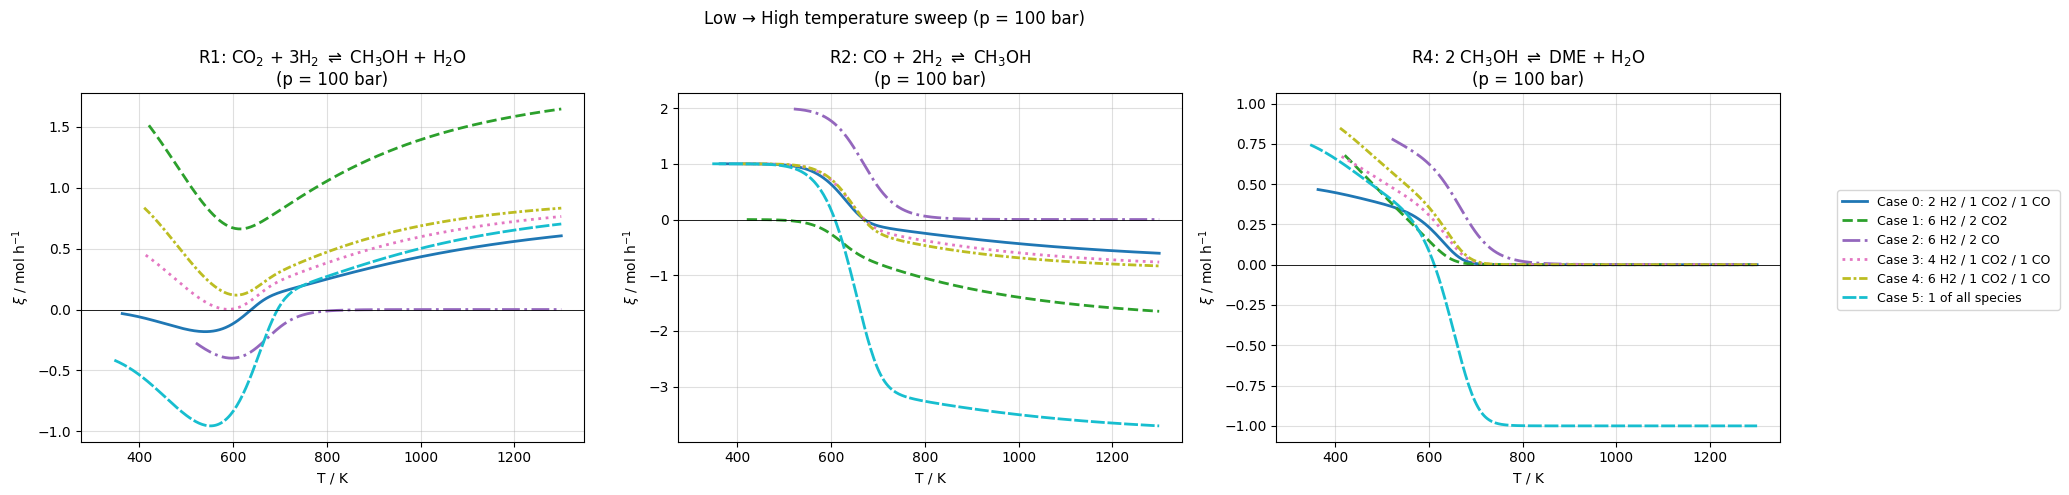

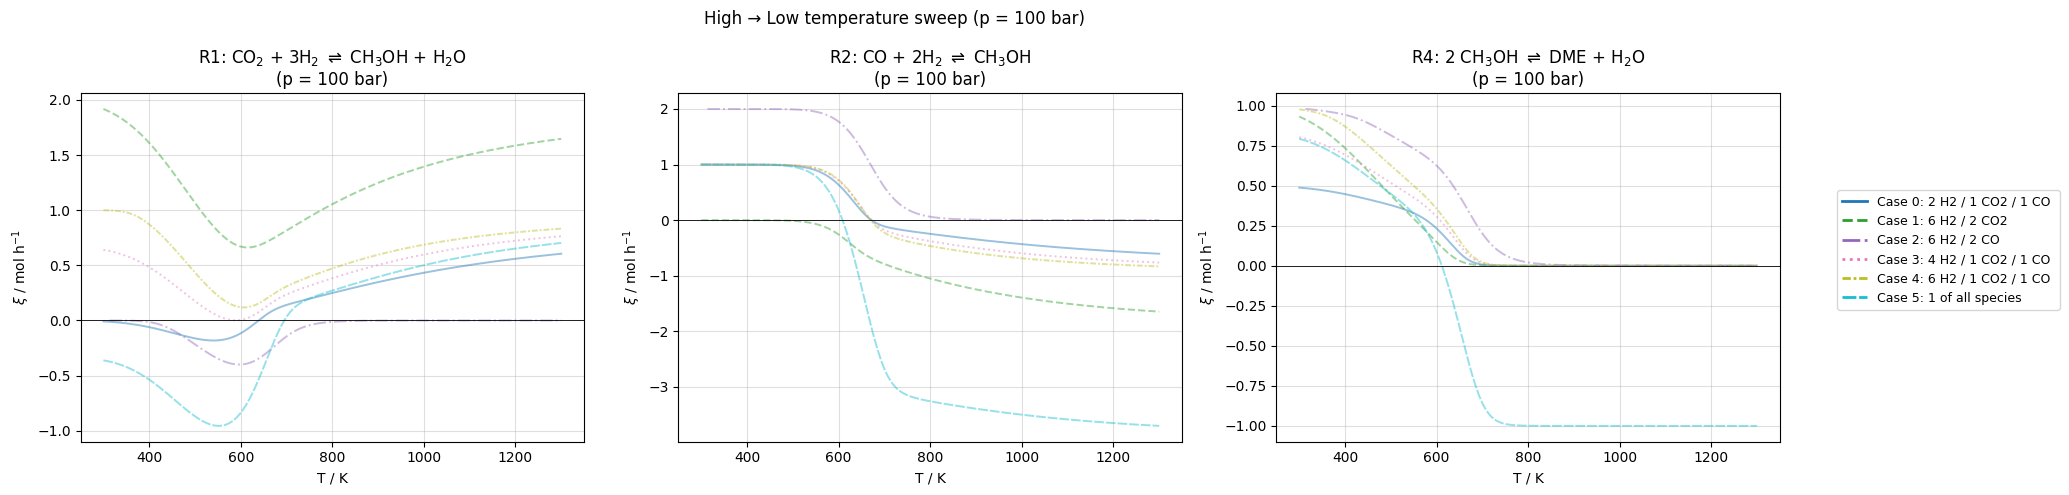

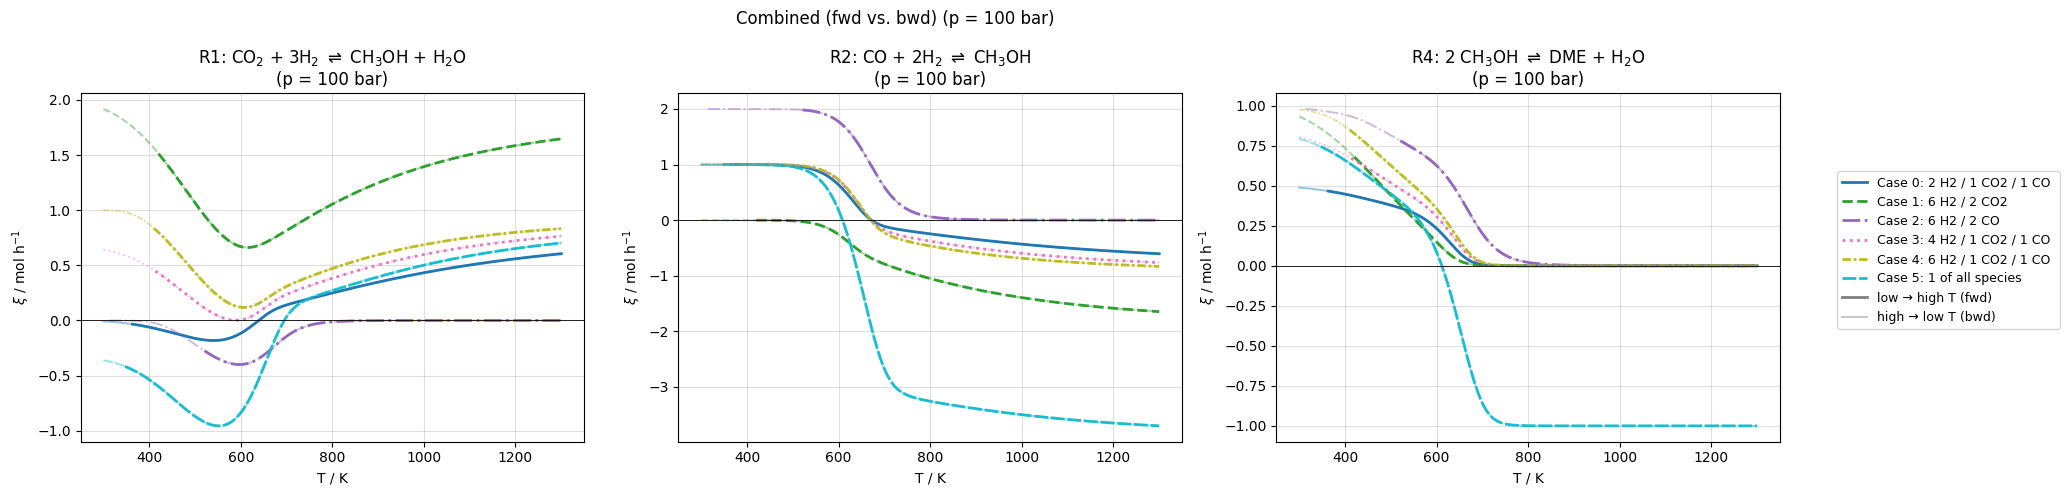

In [18]:
# =============================================================================
# ξ vs T at fixed pressure — forward and backward sweep, improved readability
#
# Encoding:
#   Color     : test case (tab10, one distinct color per case)
#   Linestyle : test case (each case gets a unique linestyle)
#   Alpha/lw  : sweep direction (fwd = full opacity/thick, bwd = faded/thin)
# =============================================================================

from matplotlib.lines import Line2D

# --- Temperature grid ---
T_range = np.linspace(300, 1300, 300)
p_fixed = 100  # bar

# --- Storage arrays ---
xi_T_fwd = np.full((len(test_cases), 3, len(T_range)), np.nan)
xi_T_bwd = np.full((len(test_cases), 3, len(T_range)), np.nan)

# --- Forward sweep: low T → high T ---
for ci, (name, n_in) in enumerate(test_cases):
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for ti, T in enumerate(T_range):
        xi = safe_solve(n_in, T, p_fixed, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_T_fwd[ci, :, ti] = xi
            xi_prev = xi

# --- Backward sweep: high T → low T ---
for ci, (name, n_in) in enumerate(test_cases):
    last_valid = next(
        (xi_T_fwd[ci, :, ti] for ti in range(len(T_range) - 1, -1, -1)
         if not np.any(np.isnan(xi_T_fwd[ci, :, ti]))),
        make_initial_guess(n_in, reaction_indices, reaction_tuples)
    )
    xi_prev = last_valid
    for ti, T in enumerate(reversed(T_range)):
        xi = safe_solve(n_in, T, p_fixed, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_T_bwd[ci, :, len(T_range) - 1 - ti] = xi
            xi_prev = xi

# --- Color and linestyle encoding ---
# One distinct color per case (tab10 gives 10 well-separated colors)
case_colors = plt.cm.tab10(np.linspace(0, 1, len(test_cases)))

# One distinct linestyle per case
case_linestyles = ['-', '--', '-.', ':', (0, (3,1,1,1)), (0, (5,1))]

# Sweep direction encoded by marker/alpha only (fwd: full opacity, bwd: lower alpha)
sweep_alpha = {'fwd': 1.0, 'bwd': 0.45}
sweep_lw    = {'fwd': 2.0, 'bwd': 1.4}

# --- Plot configuration ---
plot_configs = [
    ('Low → High temperature sweep',  [(xi_T_fwd, 'fwd')]),
    ('High → Low temperature sweep',  [(xi_T_bwd, 'bwd')]),
    ('Combined (fwd vs. bwd)',         [(xi_T_fwd, 'fwd'), (xi_T_bwd, 'bwd')]),
]

for fig_title, sweep_configs in plot_configs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for r_idx in range(3):
        for xi_data, sweep_label in sweep_configs:
            for ci, (name, n_in) in enumerate(test_cases):
                axes[r_idx].plot(
                    T_range, xi_data[ci, r_idx, :],
                    color=case_colors[ci],
                    linestyle=case_linestyles[ci],
                    lw=sweep_lw[sweep_label],
                    alpha=sweep_alpha[sweep_label],
                )

        axes[r_idx].set_xlabel('T / K')
        axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
        axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(p = {p_fixed} bar)')
        axes[r_idx].grid(True, alpha=0.4)
        axes[r_idx].axhline(0, color='k', lw=0.6)

    # --- Legend ---
    # Case entries (color + linestyle)
    legend_entries = [
        Line2D([0], [0], color=case_colors[ci],
               linestyle=case_linestyles[ci], lw=2.0,
               label=name)
        for ci, (name, _) in enumerate(test_cases)
    ]
    # Sweep direction entries (alpha difference explained)
    if len(sweep_configs) > 1:
        legend_entries += [
            Line2D([0], [0], color='gray', lw=2.0, alpha=1.0,  label='low → high T (fwd)'),
            Line2D([0], [0], color='gray', lw=1.4, alpha=0.45, label='high → low T (bwd)'),
        ]

    fig.legend(
        handles=legend_entries,
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        fontsize=9, frameon=True
    )
    fig.suptitle(f'{fig_title} (p = {p_fixed} bar)', fontsize=12)
    plt.tight_layout()
    plt.show()

The visualization above shows the reaction extent of reactions 1, 2 and 4 in a temperature range of 300 to 1300 K. This range was chosen, as above these temperatures the reaction extent of R4, the dehydration of methanol, was expected to converge to zero. As the plots show, this expectation holds true, and the reaction extent of R4 approaches zero for all temperatures above 900 K. For the reactions themselves, we can observe the following:

### Case 0/3/4 (Case 0: 2 $\mathrm{H}_2$ / 1 $\mathrm{CO}_2$ / 1 $\mathrm{CO}$, Case 3: 4 $\mathrm{H}_2$ / 1 $\mathrm{CO}_2$ / 1 $\mathrm{CO}$, Case 4: 6 $\mathrm{H}_2$ / 1 $\mathrm{CO}_2$ / 1 $\mathrm{CO}$):

In all these cases, the syngas consists of a mixture of equal shares of $\mathrm{CO}$ and $\mathrm{CO}_2$, with varying $\mathrm{H}_2$ contents of 2, 4 and 6 moles respectively for Cases 0, 3 and 4. All three cases show similar reaction extents for all reactions, with minor deviations from each other. For Case 0, the reaction extent of R1 starts in the negative range, meaning that methanol is consumed rather than formed. The thermodynamic root cause is the $\mathrm{H}_2$-limited feed: since R1 requires 3 mol $\mathrm{H}_2$ per mol methanol formed while R2 requires only 2, R2 is stoichiometrically favoured and consumes all available $\mathrm{H}_2$. As a result, R1 runs in reverse to satisfy the overall equilibrium condition, consuming the methanol formed by R2 rather than contributing to DME formation via R4. This hypothesis is strengthened by the reaction extent of R4, which is the lowest of all three cases with $\mathrm{CO}$ and $\mathrm{CO}_2$ as feedstock. For Cases 3 and 4, where more $\mathrm{H}_2$ is present, the reaction extent of R1 starts positive at low temperatures, since sufficient $\mathrm{H}_2$ is now available to drive both R1 and R2 in the forward direction simultaneously. The Gibbs free energy of R2 is lower than that of R1 at low temperatures, meaning R2 proceeds more spontaneously; however, with excess $\mathrm{H}_2$, R1 can also contribute positively to methanol formation.

The cases show that a higher $\mathrm{H}_2$ content in the feed leads to a higher reaction extent of R4 for Cases 0, 3 and 4. At higher temperatures the reaction extents converge to zero, but at lower temperatures Case 4 shows the highest reaction extent, with Case 3 in between. The same behaviour is observed for R1, where Case 4 shows the highest reaction extent at low temperatures. A higher reaction extent of R1 means more methanol is formed, which is subsequently available for DME production via R4.

R2 shows the same reaction extent of 1 for all three cases, meaning that essentially all of the $\mathrm{CO}$ fed into the system is consumed (see the definition of the reaction extent, Eq. 5). This directly follows from the fact that all three cases contain exactly 1 mol $\mathrm{CO}$ in the feed, so $\xi_{R2} = 1$ corresponds to complete conversion of $\mathrm{CO}$, consistent with Eq. 5. This also confirms that R2 is preferred over R1 at low temperatures, as all of the incoming $\mathrm{CO}$ reacts with $\mathrm{H}_2$, while R1 is only able to consume the remaining available $\mathrm{H}_2$. In Case 0, no $\mathrm{H}_2$ remains after R2, which is why the reverse reaction of R1 occurs rather than the forward reaction.

At approximately 550 K the behaviour shifts: the reaction extent of R2 begins to decline, while the reaction extent of R1 increases. As shown in Section 4.6, the Gibbs free energy of the reactions is pressure-dependent. At 100 bar, the transition from exergonic to endergonic behaviour for R2 occurs at approximately 600 K. Above this temperature, R2 increasingly proceeds in reverse, consuming methanol. In accordance with Le Chatelier's principle, R1 compensates for this disturbance of the equilibrium by increasing its forward extent, forming additional methanol from the $\mathrm{H}_2$ available in the feed. The hypothesis that R2 (in reverse) consumes all methanol formed by R1 is confirmed by the reaction extent of R4 approaching zero above approximately 800 K.

### Case 1/2 (Case 1: 6 $\mathrm{H}_2$ / 2 $\mathrm{CO}_2$, Case 2: 6 $\mathrm{H}_2$ / 2 $\mathrm{CO}$):

For Case 1, the feed contains only $\mathrm{CO}_2$ and $\mathrm{H}_2$; for Case 2 only $\mathrm{CO}$ and $\mathrm{H}_2$. Accordingly, only negative values or zero are observed for the reaction extent of R2 in Case 1, and for R1 in Case 2. This is because if no reactant for a given reaction is present in the feed, no positive reaction extent is possible by definition (Eq. 5); only the reverse reaction can occur to satisfy the equilibrium condition.

For Case 2, the reaction extent of R1 is negative at low temperatures. This is expected: since no $\mathrm{CO}_2$ is present, only the reverse of R1 can proceed, consuming methanol formed by R2. The reaction extent of R1 converges toward zero as temperature increases, coinciding with the reaction extent of R2 also approaching zero. This means the reverse reaction of R1 no longer consumes methanol once R2 ceases to form it, which is the expected behaviour. R4 follows the same trend, as the dehydration of methanol can no longer proceed once no methanol is being formed. The reaction extent of R2 starting at 2 for Case 2 is explained directly by the definition of $\xi$ (Eq. 5) and the feed of 2 mol $\mathrm{CO}$.

For Case 1, the reaction extent of R1 starts positive, declines until approximately 600 K, and then rises again. The rise coincides with the reaction extent of R2 becoming negative, meaning the explanation is the same as discussed above: R2 reverses and consumes methanol, which disturbs the equilibrium and drives R1 forward in accordance with Le Chatelier's principle to compensate. The same rise coincides with the reaction extent of R4 approaching zero, confirming that the reverse of R2 likely consumes all methanol formed by R1.

### Case 5 (Case 5: 1 mol of all species):

For Case 5, R1 starts with a negative reaction extent, R2 starts with a reaction extent of 1 (complete conversion of the 1 mol $\mathrm{CO}$ feed), and R4 also starts with a positive reaction extent. The general trends in the decline and subsequent increase of the reaction extents follow the same mechanisms discussed for the other cases. Additionally, in this case the reaction extent of R4 drops not only to zero but to $-1$. This is expected, as Case 5 includes DME in the feed stream. At high temperatures, the reverse of R2 consumes all available and newly formed methanol. This drives the reverse of R4 as well, since the system attempts to restore the methanol equilibrium by decomposing DME. As DME is present in the feed (uniquely in Case 5), the resulting reaction extent of R4 becomes negative, meaning less DME is present at the outlet than at the inlet.

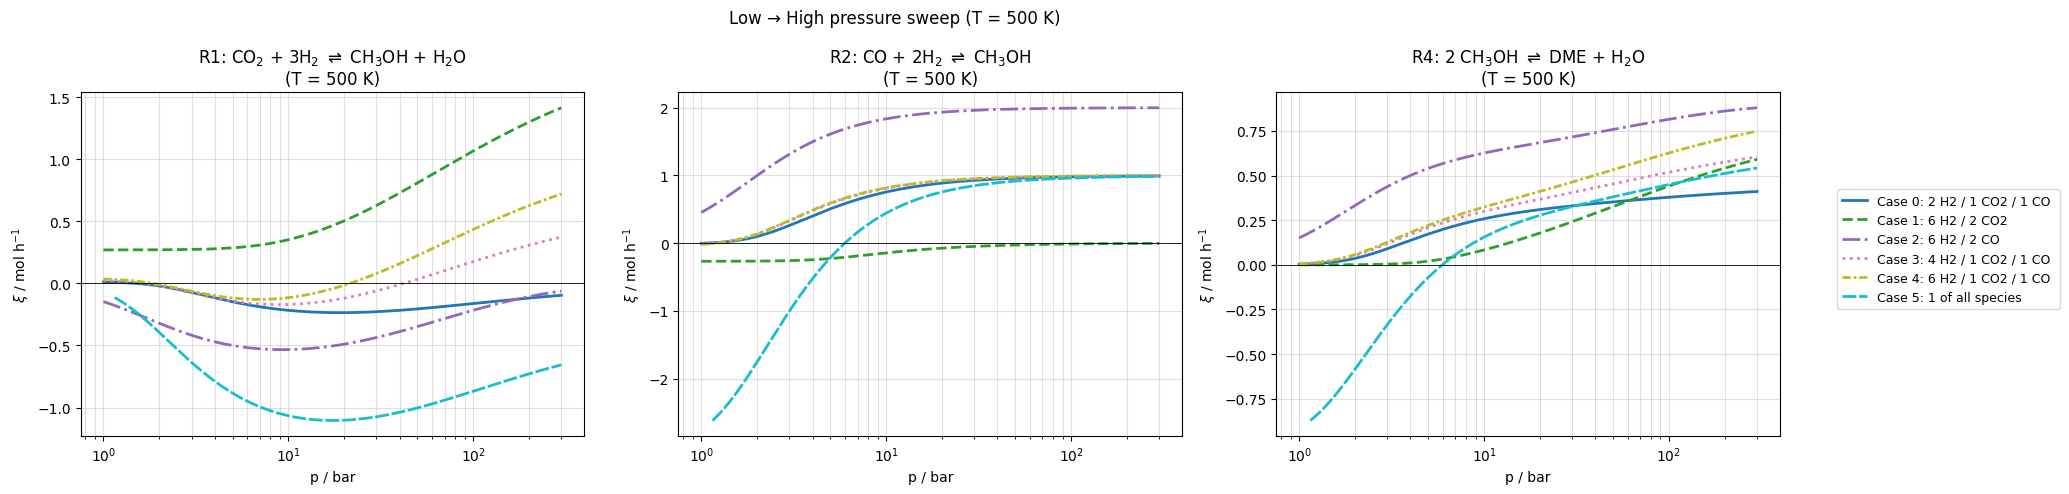

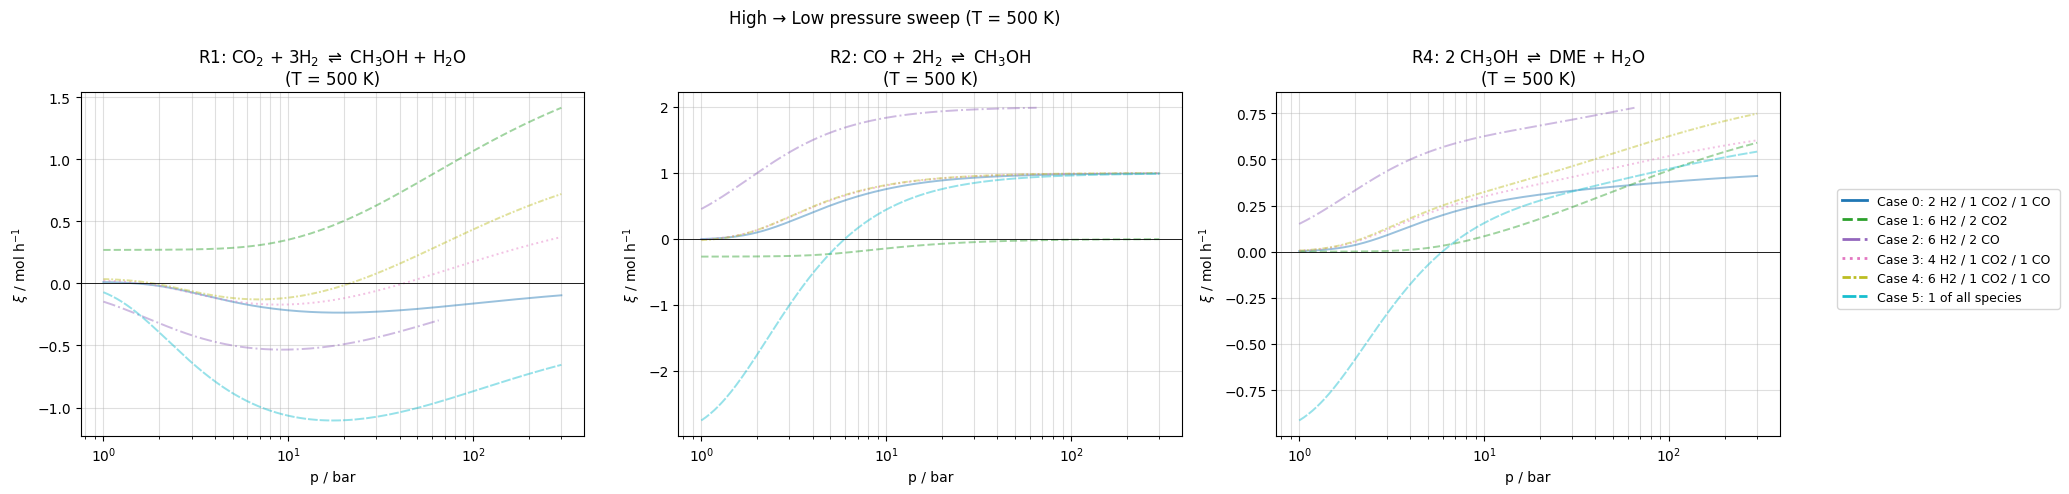

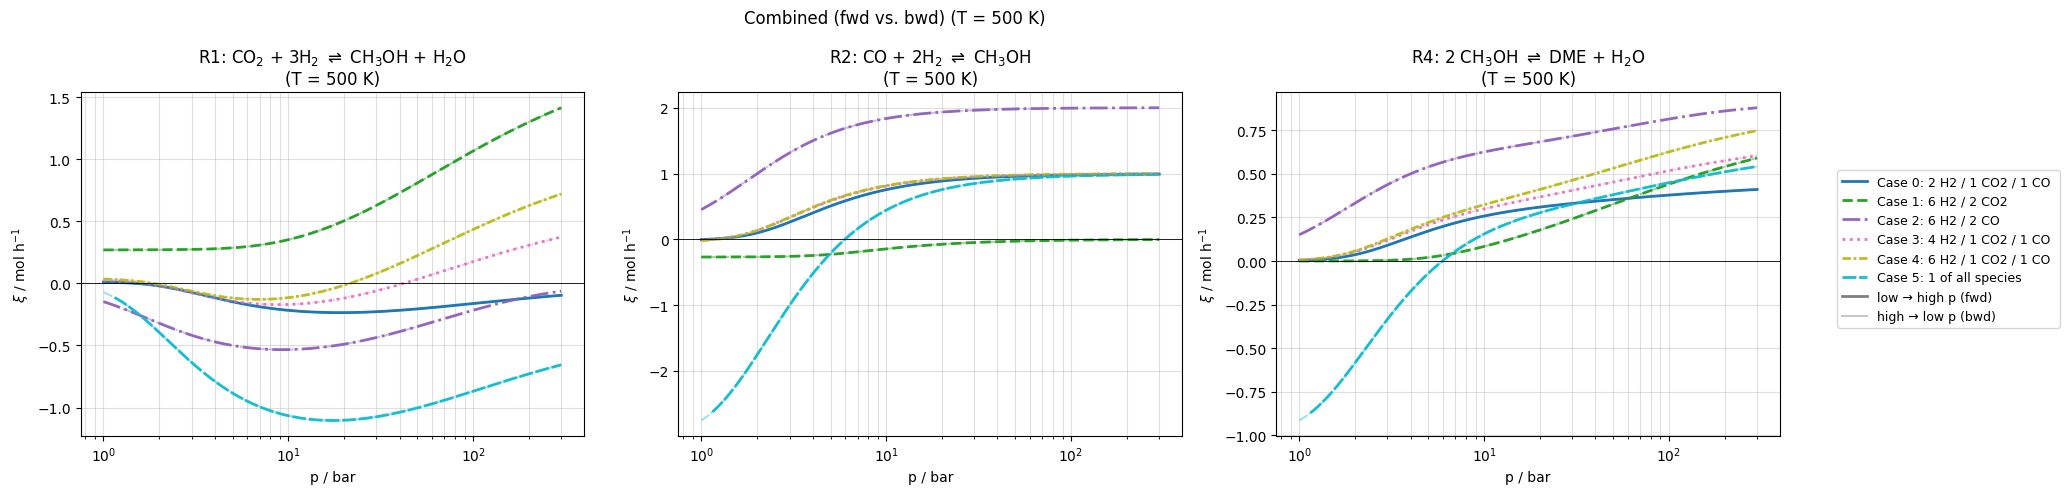

In [20]:
from matplotlib.lines import Line2D

# --- Pressure grid ---
# Dense resolution in the low-pressure region (1–10 bar) where nonlinear
# behaviour and potential discontinuities are most pronounced.
p_critical_region = np.linspace(1, 10, 300)
p_smooth_high     = np.logspace(np.log10(10), np.log10(300), 50)
p_range           = np.concatenate([p_critical_region[:-1], p_smooth_high])

T_fixed = 500  # K — representative DME synthesis temperature

# --- Storage arrays for both sweep directions ---
# Shape: (n_cases, n_reactions, n_pressure_points)
xi_p_fwd = np.full((len(test_cases), 3, len(p_range)), np.nan)  # low → high
xi_p_bwd = np.full((len(test_cases), 3, len(p_range)), np.nan)  # high → low

# --- Forward sweep: low → high pressure ---
for ci, (name, n_in) in enumerate(test_cases):
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for pi, p in enumerate(p_range):
        xi = safe_solve(n_in, T_fixed, p, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_p_fwd[ci, :, pi] = xi
            xi_prev = xi  # warm-start next step from current solution

# --- Backward sweep: high → low pressure ---
for ci, (name, n_in) in enumerate(test_cases):
    xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
    for pi, p in enumerate(reversed(p_range)):
        xi = safe_solve(n_in, T_fixed, p, xi_init=xi_prev, xi_prev=xi_prev)
        if not np.any(np.isnan(xi)):
            xi_p_bwd[ci, :, len(p_range) - 1 - pi] = xi  # store at correct index
            xi_prev = xi

# --- Color and linestyle convention ---
# One distinct color per case (tab10), sweep direction encoded by alpha and linewidth only
case_colors = plt.cm.tab10(np.linspace(0, 1, len(test_cases)))
case_linestyles = ['-', '--', '-.', ':', (0, (3,1,1,1)), (0, (5,1))]

sweep_alpha = {'fwd': 1.0, 'bwd': 0.45}
sweep_lw    = {'fwd': 2.0, 'bwd': 1.4}

# --- Plot configuration: three separate figures ---
plot_configs = [
    ('Low → High pressure sweep',  [(xi_p_fwd, 'fwd')]),
    ('High → Low pressure sweep',  [(xi_p_bwd, 'bwd')]),
    ('Combined (fwd vs. bwd)',      [(xi_p_fwd, 'fwd'), (xi_p_bwd, 'bwd')]),
]

for fig_title, sweep_configs in plot_configs:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for r_idx in range(3):
        for xi_data, sweep_label in sweep_configs:
            for ci, (name, n_in) in enumerate(test_cases):
                axes[r_idx].plot(
                    p_range, xi_data[ci, r_idx, :],
                    color=case_colors[ci],
                    linestyle=case_linestyles[ci],
                    lw=sweep_lw[sweep_label],
                    alpha=sweep_alpha[sweep_label],
                )

        axes[r_idx].set_xlabel('p / bar')
        axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
        axes[r_idx].set_xscale('log')
        axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(T = {T_fixed} K)')
        axes[r_idx].grid(True, alpha=0.4, which='both')
        axes[r_idx].axhline(0, color='k', lw=0.6)

    # --- Legend ---
    legend_entries = [
        Line2D([0], [0], color=case_colors[ci],
               linestyle=case_linestyles[ci], lw=2.0,
               label=name)
        for ci, (name, _) in enumerate(test_cases)
    ]
    if len(sweep_configs) > 1:
        legend_entries += [
            Line2D([0], [0], color='gray', lw=2.0, alpha=1.0,  label='low → high p (fwd)'),
            Line2D([0], [0], color='gray', lw=1.4, alpha=0.45, label='high → low p (bwd)'),
        ]

    fig.legend(
        handles=legend_entries,
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        fontsize=9, frameon=True
    )
    fig.suptitle(f'{fig_title} (T = {T_fixed} K)', fontsize=12)
    plt.tight_layout()
    plt.show()

The plots above show the reaction extent of reactions R1, R2 and R4 as a function of pressure at a fixed temperature of 500 K. The forward (low to high pressure) and backward (high to low pressure) sweeps overlap closely for all cases, confirming that the solver converges to the same physical solution regardless of the sweep direction and that the results are numerically robust.

For all three reactions, the reaction extent increases with pressure. This is consistent with the thermodynamic analysis in Section 4.6: both R1 ($\Delta\nu = -2$) and R2 ($\Delta\nu = -2$) proceed with a net reduction in the total number of moles, so an increase in pressure shifts the equilibrium toward the products in accordance with Le Chatelier's principle. R4 ($\Delta\nu = 0$) carries no intrinsic pressure dependence through $K^\circ$, but benefits indirectly from the increased methanol availability driven by R1 and R2 at higher pressures.

At low pressures (below approximately 5 bar), the reaction extents of R1 are negative for most cases, meaning the reverse reaction is favoured. This is consistent with the pressure-corrected Gibbs free energy shown in Section 4.6, where $\Delta_R G(T, p)$ for R1 is still positive at low pressures and 500 K. Only above a certain threshold pressure does R1 become exergonic and the forward reaction extent turns positive. For R2, the transition from negative to positive reaction extent occurs at lower pressures than for R1, again reflecting the lower Gibbs free energy of R2 compared to R1 at these conditions.

Cases 1 and 2, which contain only one carbon oxide species ($\mathrm{CO}_2$ or $\mathrm{CO}$ respectively), show the highest reaction extents for their respective favoured reaction: Case 1 reaches the highest $\xi_{R1}$ values, while Case 2 reaches the highest $\xi_{R2}$ values. This is expected, as the absence of the competing carbon oxide species means all available $\mathrm{H}_2$ is directed into a single methanol synthesis pathway. Cases 0, 3 and 4, which contain both $\mathrm{CO}$ and $\mathrm{CO}_2$, show intermediate reaction extents, with higher $\mathrm{H}_2$ contents (Cases 3 and 4) yielding higher extents than the $\mathrm{H}_2$-limited Case 0. Case 5, which includes all species including DME in the feed, shows the most negative reaction extents at low pressures due to the reverse reactions being driven by the presence of products already in the feed.

For R4, all cases show a monotonically increasing reaction extent with pressure, converging toward a plateau at high pressures. The ranking of the cases mirrors that of R1 and R2: feeds that produce more methanol at a given pressure also yield a higher reaction extent for the dehydration step. This confirms that the pressure dependence of the overall DME yield is governed primarily by the methanol synthesis reactions R1 and R2, with R4 responding to the methanol availability they provide.

Overall, higher pressures consistently yield higher reaction extents across all cases, with the effect being most pronounced at intermediate pressures and saturating toward the high-pressure plateau.

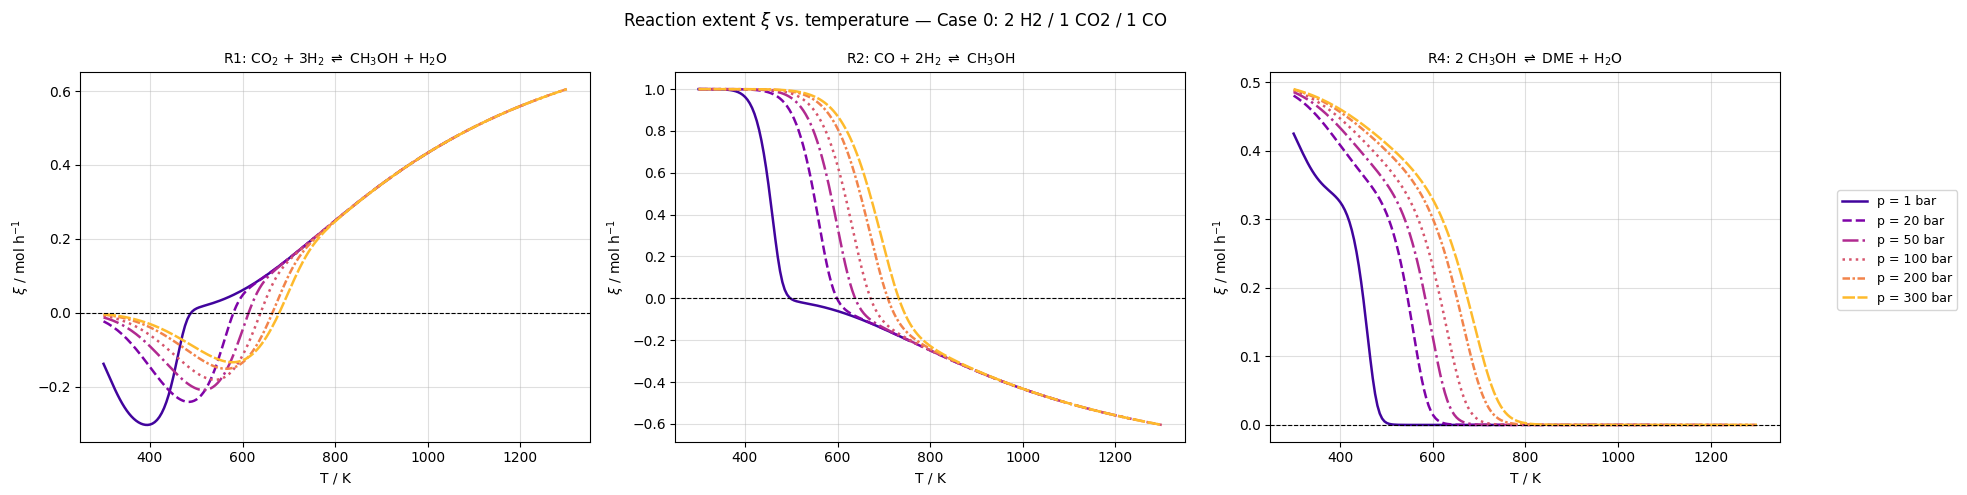

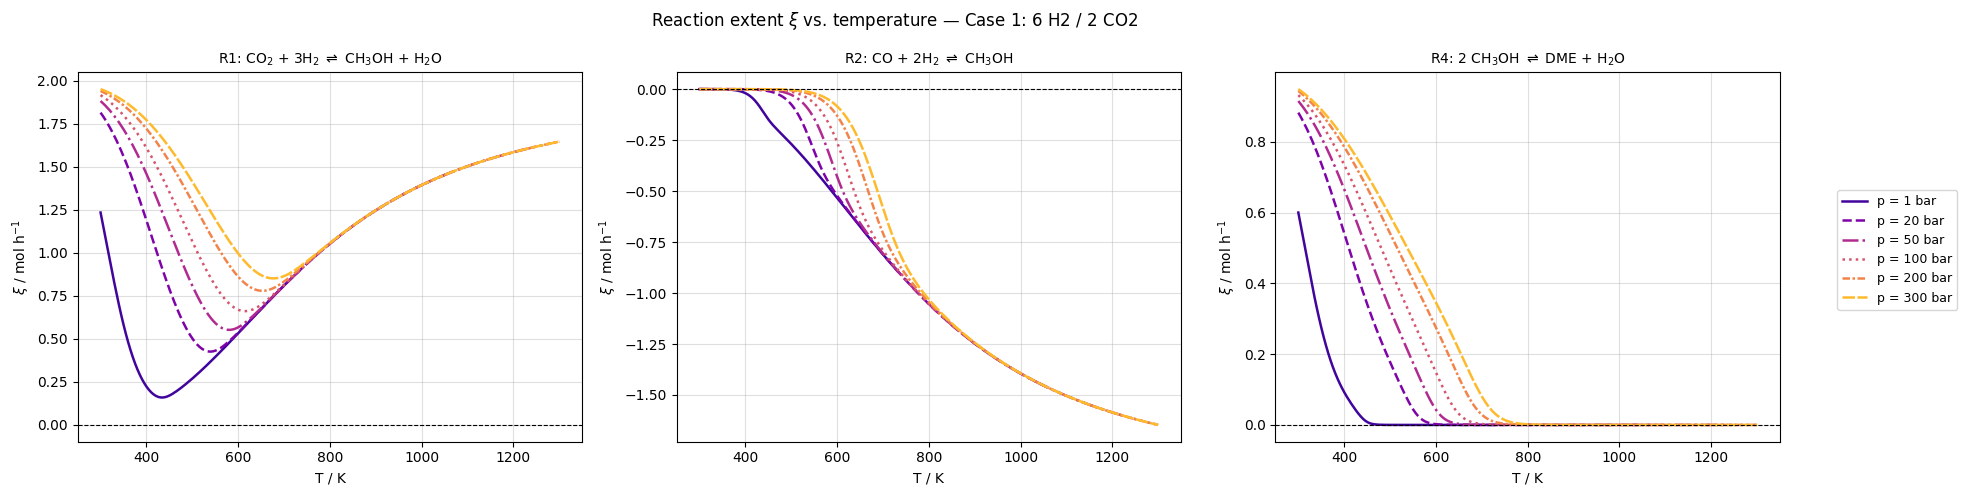

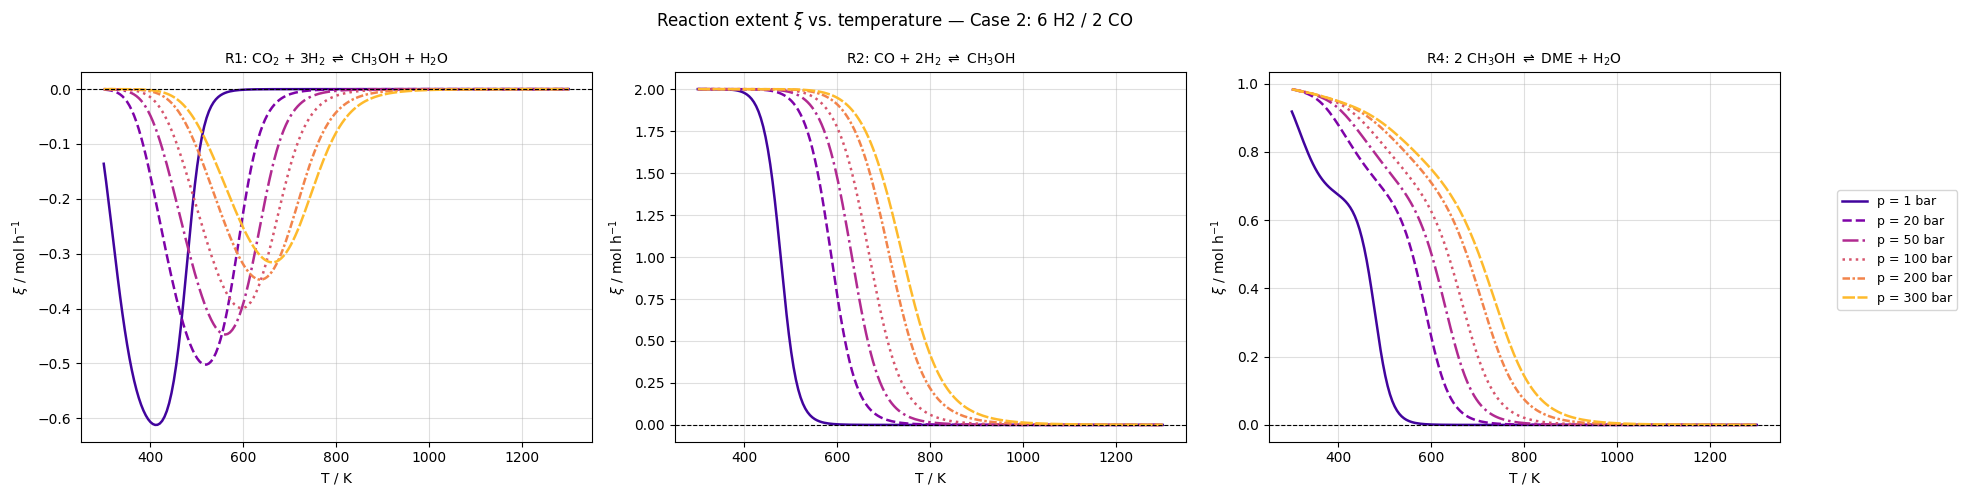

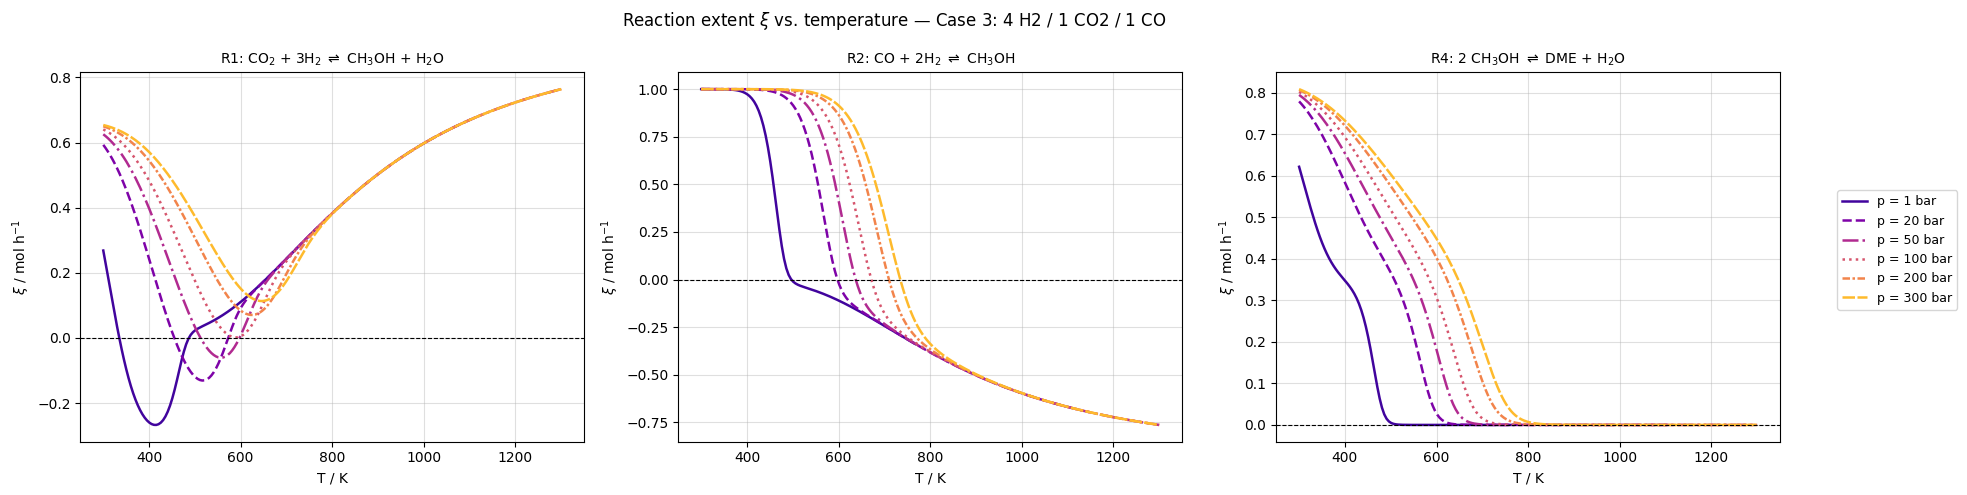

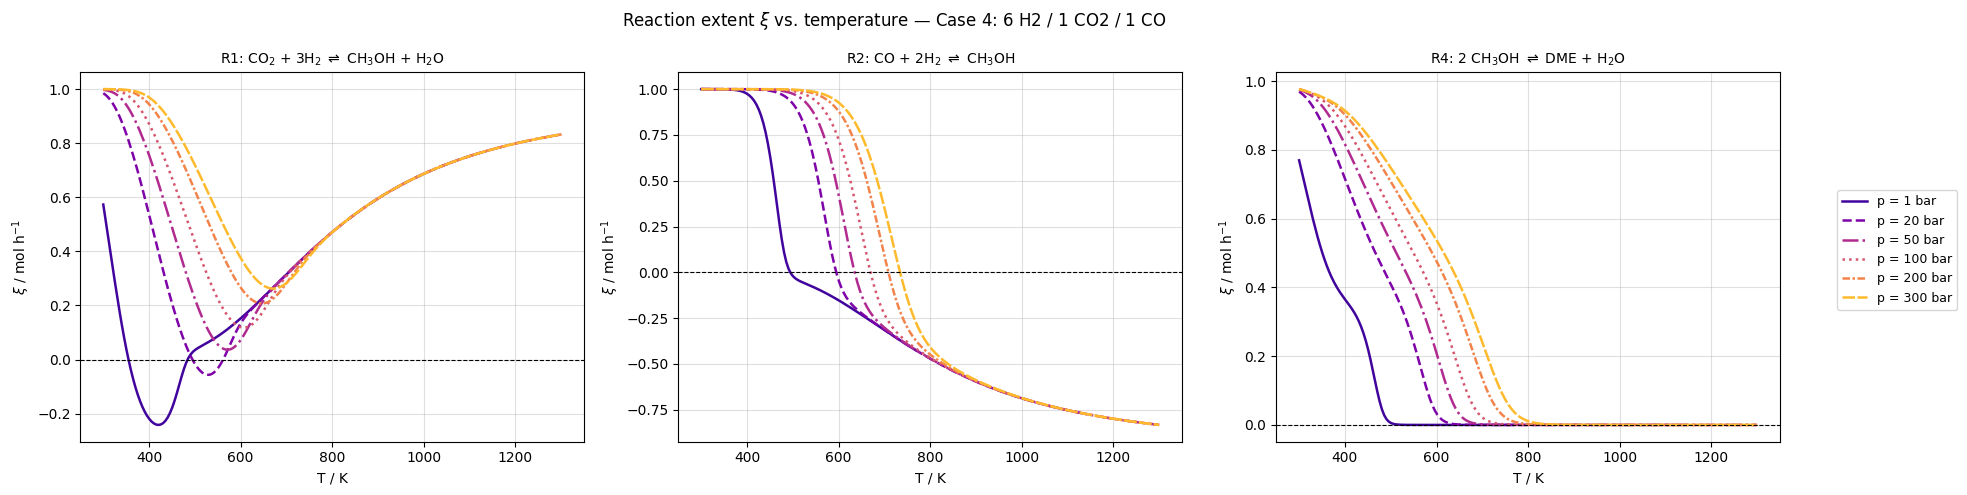

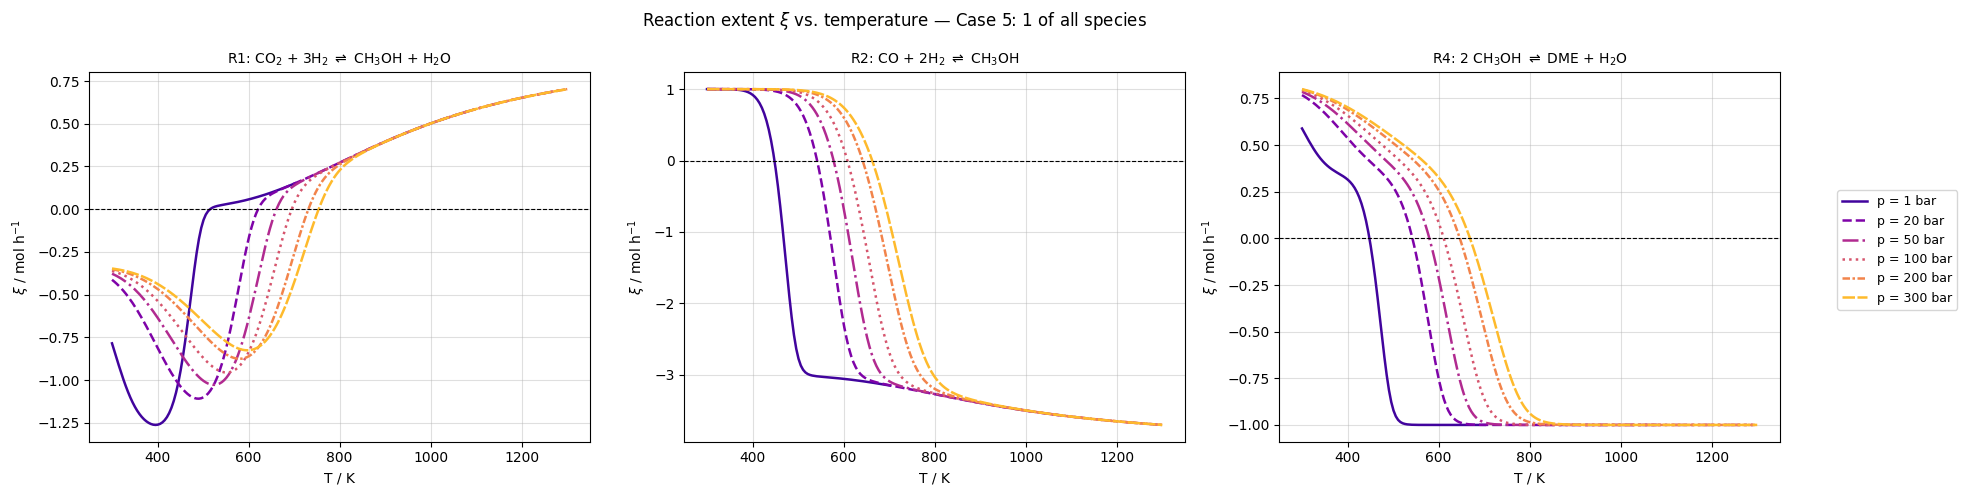

In [21]:
# =============================================================================
# ξ vs T at fixed pressures — 2D line plots for six pressure levels
#
# For each test case, one figure with 3 subplots (one per reaction) is shown.
# Each subplot contains six curves, one per pressure level.
# Both a forward (low T → high T) and a backward (high T → low T) sweep are
# performed per pressure, warm-started from the previous step for solver
# stability; the backward sweep fills any gaps left by the forward sweep.
# =============================================================================

# --- Parameters ---
T_range_2d = np.linspace(300, 1300, 200)          # Temperature range [K]
pressures_2d = [1, 20, 50, 100, 200, 300]         # Pressure levels [bar]

# Distinguish pressure levels by both color and linestyle
p_colors_2d    = plt.cm.plasma(np.linspace(0.1, 0.85, len(pressures_2d)))
p_linestyles_2d = ['-', '--', '-.', ':', (0, (3,1,1,1)), (0, (5,1))]

# --- Compute ξ(T) for all cases and pressures — forward and backward sweep ---
# Shape: (n_cases, n_pressures, n_reactions, n_temperatures)
xi_2d = np.full((len(test_cases), len(pressures_2d), 3, len(T_range_2d)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    for pi, p in enumerate(pressures_2d):

        # --- Forward sweep: low T → high T ---
        xi_prev = make_initial_guess(n_in, reaction_indices, reaction_tuples)
        for ti, T in enumerate(T_range_2d):
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_2d[ci, pi, :, ti] = xi
                xi_prev = xi

        # --- Backward sweep: high T → low T ---
        # Start from the last valid solution of the forward sweep instead of
        # make_initial_guess — this avoids a discontinuous jump at the right edge.
        last_valid = next(
            (xi_2d[ci, pi, :, ti] for ti in range(len(T_range_2d) - 1, -1, -1)
             if not np.any(np.isnan(xi_2d[ci, pi, :, ti]))),
            make_initial_guess(n_in, reaction_indices, reaction_tuples)
        )
        xi_prev = last_valid

        for ti, T in enumerate(reversed(T_range_2d)):
            real_ti = len(T_range_2d) - 1 - ti
            if not np.any(np.isnan(xi_2d[ci, pi, :, real_ti])):
                xi_prev = xi_2d[ci, pi, :, real_ti]
                continue
            xi = safe_solve(n_in, T, p, xi_init=xi_prev, xi_prev=xi_prev)
            if not np.any(np.isnan(xi)):
                xi_2d[ci, pi, :, real_ti] = xi
                xi_prev = xi

# --- Plotting: one figure per test case ---
for ci, (name, n_in) in enumerate(test_cases):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for r_idx in range(3):
        ax = axes[r_idx]

        for pi, p in enumerate(pressures_2d):
            ax.plot(
                T_range_2d,
                xi_2d[ci, pi, r_idx, :],
                color=p_colors_2d[pi],
                linestyle=p_linestyles_2d[pi],
                linewidth=1.8,
                label=f'p = {p} bar'
            )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xlabel('T / K', fontsize=10)
        ax.set_ylabel(r'$\xi$ / mol h$^{-1}$', fontsize=10)
        ax.set_title(f'{reaction_labels_short[r_idx]}', fontsize=10)
        ax.grid(True, alpha=0.4)

    # Shared legend to the right
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc='center left', bbox_to_anchor=(1.02, 0.5),
        fontsize=9, frameon=True
    )
    fig.suptitle(f'Reaction extent $\\xi$ vs. temperature — {name}', fontsize=12)
    plt.tight_layout()
    plt.show()

The plots above show the reaction extent of R1, R2 and R4 as a function of temperature for each test case at six pressure levels. The following discussion addresses first the general behavior shared across all cases, then the influence of the $\mathrm{CO}$/$\mathrm{CO}_2$ ratio, and finally the influence of the $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio.

### General behavior and influence of the $\mathrm{CO}$/$\mathrm{CO}_2$ ratio

R4 carries no intrinsic pressure dependence through $K^\circ$, as established in Section 4.6, since $\Delta\nu_{R4} = 0$. However, R4 is affected indirectly through the methanol supply provided by R1 and R2, both of which are pressure-dependent. This indirect coupling is visible in all cases: the R4 curves are separated across pressure levels in the same temperature range where R1 and R2 show pressure sensitivity. At high temperatures, R1 and R2 lose their pressure dependence as their curves converge across all pressure levels — for example, above approximately 800 K in Case 0. Since R4 becomes thermodynamically unfavorable above a certain temperature regardless of pressure, as shown in Section 4.6, the reaction extent of R4 approaches zero in this regime even when methanol continues to be supplied by R1. R2 shows pressure dependence primarily in the intermediate temperature range of approximately 400–1000 K; outside this window, the curves for all pressures converge and pressure ceases to have a meaningful effect on the equilibrium.

In Case 0 (2 $\mathrm{H}_2$ / 1 $\mathrm{CO}_2$ / 1 $\mathrm{CO}$), the reaction extent of R1 is negative at low temperatures and crosses zero at approximately the same temperature at which R2 begins to decline, but in the opposite direction. This is a direct consequence of the Gibbs free energy of R1 being higher than that of R2 across the relevant temperature range, as shown in Section 4.6: R2 forms methanol from $\mathrm{CO}$ while R1 runs in reverse, consuming the methanol produced by R2. Above approximately 500–600 K this relationship inverts — R1 begins to form methanol while R2 starts to run in reverse as $\mathrm{CO}$-based methanol synthesis becomes thermodynamically unfavorable. The non-monotonic behavior of R1 in Case 0, where $\xi_{R1}$ crosses zero at approximately 400 K for 1 bar, then curves downward before rising again at higher temperatures, is absent in Case 2 (pure $\mathrm{CO}$ feed) and must therefore be a consequence of $\mathrm{CO}_2$ in the feed: once R2 begins to produce methanol, the resulting excess methanol shifts the equilibrium of R1 backward, suppressing its forward extent temporarily. The inflection point visible in R4 at approximately 400 K at 1 bar in Case 0 reflects the onset of methanol supply from R2, since this feature is absent in Case 1 where no $\mathrm{CO}$ is present. The R4 profile of Case 0 can be understood as an overlay of the R4 profiles from Cases 1 and 2, directly demonstrating that the DME formation step depends on the combined methanol supply from both R1 and R2 and is therefore sensitive to the $\mathrm{CO}$/$\mathrm{CO}_2$ composition of the feed.

In Case 1 (6 $\mathrm{H}_2$ / 2 $\mathrm{CO}_2$, pure $\mathrm{CO}_2$ feed), R2 shows entirely negative reaction extents across all conditions, since no $\mathrm{CO}$ is present in the feed and R2 therefore runs only in reverse, producing $\mathrm{CO}$ from methanol and water. R1 shows a minimum in reaction extent — for example at approximately 600 K at 100 bar — reflecting the temperature at which the competing effects of forward methanol synthesis and the reverse reaction driven by accumulated water reach their most unfavorable thermodynamic balance. In Case 2 (6 $\mathrm{H}_2$ / 2 $\mathrm{CO}$, pure $\mathrm{CO}$ feed), the situation is reversed: R1 shows entirely negative reaction extents since no $\mathrm{CO}_2$ is present to hydrogenate, while R2 drives methanol formation. The minimum in $\xi_{R1}$ in Case 2 results entirely from the methanol formed by R2 — once R2 ceases at higher temperatures, the methanol supply is removed and the reverse of R1 also stops, causing $\xi_{R1}$ to return toward zero.

Comparing Cases 1 and 2 for R4, the $\mathrm{CO}$-fed Case 2 consistently shows a higher reaction extent at the same temperature and pressure — for example approximately 0.6 mol $h^{-1}$ (Case 2) vs. 0.1 mol $h^{-1}$ (Case 1) at 400 K and 1 bar — and additionally exhibits the inflection point in R4 discussed above, which is absent in Case 1. This confirms that $\mathrm{CO}$ in the feed leads to more favorable conditions for DME formation via R4, likely due to the lower water co-production associated with R2 compared to R1, since water inhibits the dehydration equilibrium.

In Cases 0, 1 and 2, the reaction extent curves for all six pressure levels converge toward a single common curve above approximately 800–1000 K, confirming that pressure loses its influence on the equilibrium at high temperatures where the entropic contribution to the Gibbs free energy dominates.

Case 5 (equimolar mixture of all species, including methanol, water and DME already present in the feed) shows an overall shift toward lower reaction extents across all three reactions compared to the syngas-only cases, since the pre-existing products in the feed drive all reactions partially in reverse toward their reactants. Despite this offset, Case 5 displays the same general behavior and curve shapes as the other cases — the same temperature dependence, the same pressure sensitivity and the same convergence at high temperatures — confirming that the thermodynamic structure of the reaction network is preserved regardless of the starting composition, and that only the magnitude of $\xi$ is shifted by the presence of products in the inlet stream.

### Influence of the $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio

Comparing Cases 0 ($\mathrm{H}_2$/$\mathrm{CO}_x$ = 1), 3 ($\mathrm{H}_2$/$\mathrm{CO}_x$ = 2) and 4 ($\mathrm{H}_2$/$\mathrm{CO}_x$ = 3), with $\mathrm{CO}_x$ evenly split between $\mathrm{CO}$ and $\mathrm{CO}_2$ in all three cases, reveals the effect of increasing the hydrogen-to-carbon oxide ratio. In Case 4, which has the highest ratio of 3, R1 is more favorable at low temperatures compared to Case 0 with a ratio of 1, which is a direct consequence of the strong stoichiometric dependence of R1 on $\mathrm{H}_2$: R1 requires 3 mol $\mathrm{H}_2$ per mol $\mathrm{CO}_2$ converted, making it the reaction most sensitive to $\mathrm{H}_2$ availability. Correspondingly, R4 shows a slightly higher reaction extent in Case 4 compared to Case 0 across the same temperature range, since the increased methanol supply from R1 feeds more reactant into the dehydration step. R2, by contrast, shows virtually no sensitivity to the $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio across the three cases, as it requires only 2 mol $\mathrm{H}_2$ and is less stoichiometrically constrained at the hydrogen concentrations investigated. The effect of the $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio is also visible in R4: with increasing hydrogen content, the R4 curves shift toward higher temperatures, extending the window over which DME formation remains thermodynamically favorable. The overall conclusion from this comparison is therefore that increasing the $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio primarily benefits R1 and R4, while leaving R2 largely unaffected. Across all cases and reactions, higher pressure consistently results in higher reaction extent, in agreement with Le Chatelier's principle for reactions with $\Delta\nu < 0$.


The evaluation of the impact of the $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio on the resulting reaction extend is further visualized below: the inlet stream is set to one mole of $\mathrm{CO}$ and $\mathrm{CO}_2$, while the $\mathrm{H}_2$ content of the inlet stream is varied in such a way, that the $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio varies between 0,5 and 10.

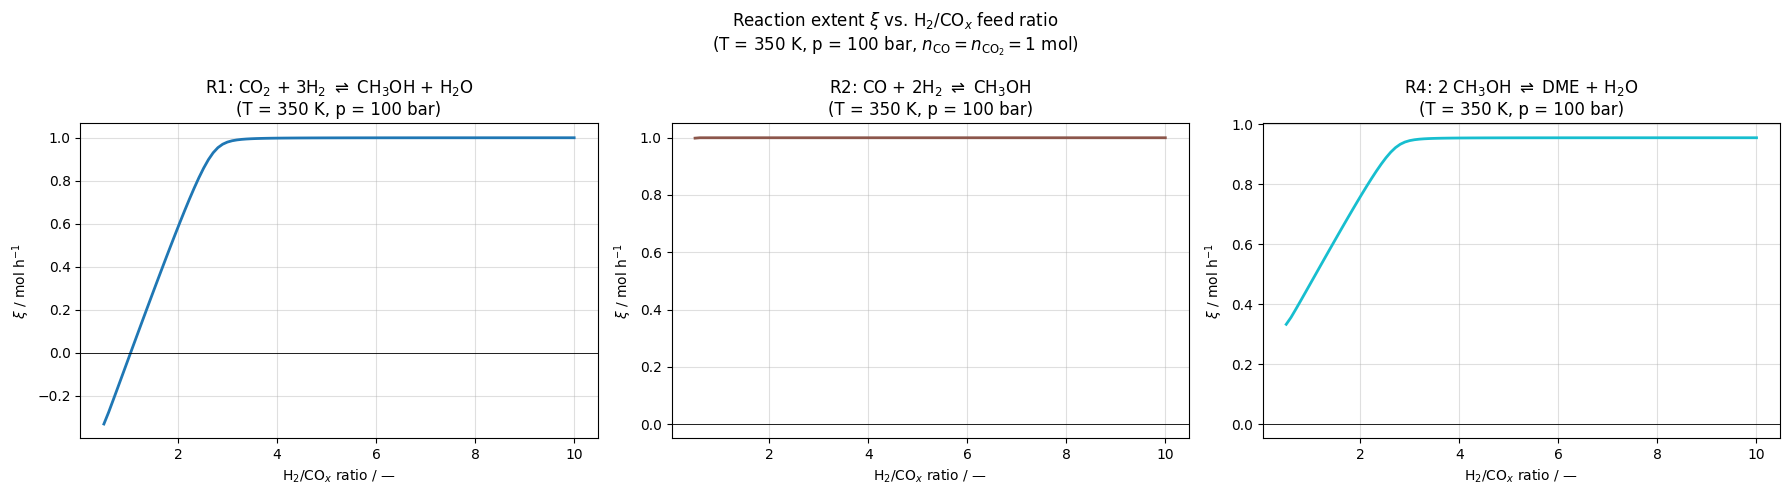

In [ ]:
# =============================================================================
# ξ vs H2/COx ratio at fixed T and p — continuous sweep with 100 points
#
# Feed cases with equal CO and CO2 amounts (1 mol each), varying H2/COx ratio
# continuously from 0.5 to 10 with 100 points.
# Fixed conditions: T = 350 K, p = 100 bar
# Continuation sweep: high → low ratio, then low → high to fill NaN gaps.
# =============================================================================

T_ratio = 350   # K
p_ratio = 100   # bar
n_cox   = 2.0   # n_CO + n_CO2 = 1 + 1 mol

h2_cox_ratios = np.linspace(0.5, 10, 100)
ratio_feeds   = [np.array([1.0, 1.0, 0.0, r * n_cox, 0.0, 0.0]) for r in h2_cox_ratios]

xi_ratio = np.full((len(h2_cox_ratios), 3), np.nan)

# --- Forward sweep: low → high H2/COx ---
xi_prev = make_initial_guess(ratio_feeds[0], reaction_indices, reaction_tuples)
for ci, n_in in enumerate(ratio_feeds):
    xi = safe_solve(n_in, T_ratio, p_ratio, xi_init=xi_prev, xi_prev=xi_prev)
    if not np.any(np.isnan(xi)):
        xi_ratio[ci, :] = xi
        xi_prev = xi

# --- Backward sweep: high → low H2/COx, fills remaining NaN gaps ---
xi_prev = make_initial_guess(ratio_feeds[-1], reaction_indices, reaction_tuples)
for ci, n_in in reversed(list(enumerate(ratio_feeds))):
    if not np.any(np.isnan(xi_ratio[ci, :])):
        xi_prev = xi_ratio[ci, :]
        continue
    xi = safe_solve(n_in, T_ratio, p_ratio, xi_init=xi_prev, xi_prev=xi_prev)
    if not np.any(np.isnan(xi)):
        xi_ratio[ci, :] = xi
        xi_prev = xi

# --- Plot ---
colors_ratio = plt.cm.tab10(np.linspace(0, 1, 3))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for r_idx in range(3):
    axes[r_idx].plot(
        h2_cox_ratios, xi_ratio[:, r_idx],
        color=colors_ratio[r_idx],
        lw=2.0,
    )
    axes[r_idx].axhline(0, color='k', lw=0.6)
    axes[r_idx].set_xlabel(r'$\mathrm{H}_2 / \mathrm{CO}_x$ ratio / —')
    axes[r_idx].set_ylabel(r'$\xi$ / mol h$^{-1}$')
    axes[r_idx].set_title(f'{reaction_labels_short[r_idx]}\n(T = {T_ratio} K, p = {p_ratio} bar)')
    axes[r_idx].grid(True, alpha=0.4)

fig.suptitle(
    r'Reaction extent $\xi$ vs. $\mathrm{H}_2/\mathrm{CO}_x$ feed ratio'
    f'\n(T = {T_ratio} K, p = {p_ratio} bar, '
    r'$n_{\mathrm{CO}} = n_{\mathrm{CO}_2} = 1$ mol)',
    fontsize=12
)
plt.tight_layout()
plt.show()

This comparison of different inlet conditions at fixed temperature and pressure shows the effect of the $\mathrm{H}_2/\mathrm{CO}_x$ feed ratio on the reaction extent of all three key reactions. R2 is favoured at all ratios due to its lower Gibbs free energy and its lower $\mathrm{H}_2$ demand (2 mol per mol methanol vs. 3 mol for R1), and reaches a reaction extent of 1 — corresponding to complete conversion of the 1 mol $\mathrm{CO}$ in the feed — across the entire range evaluated. This confirms that $\mathrm{CO}$ is fully consumed regardless of the total $\mathrm{H}_2$ availability, as long as the minimum stoichiometric requirement of R2 is met.

R1 shows a negative reaction extent at low $\mathrm{H}_2/\mathrm{CO}_x$ ratios, meaning the reverse reaction is occurring. This is consistent with the findings from the temperature analysis: when $\mathrm{H}_2$ is scarce, R2 consumes all available $\mathrm{H}_2$, leaving none for R1. To satisfy the overall equilibrium, R1 runs in reverse, consuming methanol formed by R2. As the $\mathrm{H}_2/\mathrm{CO}_x$ ratio increases, sufficient $\mathrm{H}_2$ becomes available to drive R1 in the forward direction as well. R1 reaches a reaction extent of approximately 1 — corresponding to complete conversion of the 1 mol $\mathrm{CO}_2$ in the feed — only above a ratio of approximately 3, which corresponds to the stoichiometric $\mathrm{H}_2$ requirement of R1 per mol $\mathrm{CO}_2$ converted.

The reaction extent of R4 follows directly from the methanol availability established by R1 and R2. At low $\mathrm{H}_2/\mathrm{CO}_x$ ratios, only R2 contributes methanol, limiting the DME formation via R4. As the ratio increases and R1 begins to contribute positively, more methanol becomes available and the reaction extent of R4 rises accordingly. Above a ratio of approximately 3, both R1 and R2 have reached near-complete conversion, and the reaction extent of R4 plateaus. This means that beyond this threshold, further increases in the $\mathrm{H}_2$ feed no longer lead to additional DME formation, as the system is already operating at its thermodynamic equilibrium limit for the given temperature and pressure. The optimal $\mathrm{H}_2/\mathrm{CO}_x$ feed ratio under these conditions is therefore approximately 3, as higher ratios result in unreacted $\mathrm{H}_2$ leaving the system without contributing to product formation.

# 6. Calculation of the Yield

To evaluate the overall process performance, the yield of the target product, dimethyl ether ($Y_{DME}$), is determined with respect to the total carbon oxide feed, defined as the combined inlet molar flow of $\mathrm{CO}$ and $\mathrm{CO}_2$ ($\dot{n}_{COx,in} = \dot{n}_{CO,in} + \dot{n}_{CO_2,in}$). This normalization ensures that the yield is directly comparable across all feed compositions investigated, regardless of whether the carbon source is purely $\mathrm{CO}_2$, purely $\mathrm{CO}$, or a mixture of both.

By combining the individual reaction steps of the network, two global stoichiometric equations for direct DME synthesis can be formulated, one for each carbon source:

$$2\,\mathrm{CO_2} + 6\,\mathrm{H_2} \rightleftharpoons \mathrm{CH_3OCH_3} + 3\,\mathrm{H_2O} \tag{23}$$

$$2\,\mathrm{CO} + 4\,\mathrm{H_2} \rightleftharpoons \mathrm{CH_3OCH_3} + \mathrm{H_2O} \tag{24}$$

In both cases, the stoichiometric ratio of carbon oxide to DME is $|\nu_{COx}| / |\nu_{DME}| = 2$, so a single unified yield expression applies regardless of feed composition:

$$Y_{DME} = \frac{|\nu_{COx}|}{|\nu_{DME}|} \cdot \frac{\dot{n}_{DME,out} - \dot{n}_{DME,in}}{\dot{n}_{COx,in}} = 2 \cdot \frac{\dot{n}_{DME,out} - \dot{n}_{DME,in}}{\dot{n}_{CO,in} + \dot{n}_{CO_2,in}} \tag{25}$$

To verify this implementation, the reference scenario Case 0 was evaluated, using a feed of 2 mol/h $\mathrm{H_2}$, 1 mol/h $\mathrm{CO_2}$ and 1 mol/h $\mathrm{CO}$. At industrially relevant operating conditions of 500 K and 100 bar, the numerical solver computed a final DME production of 0.3784 mol/h. With a total carbon oxide feed of $\dot{n}_{COx,in} = 2$ mol/h, this corresponds to an equilibrium yield of 37.84%. This result demonstrates that even under highly favorable high-pressure and low-temperature conditions, the maximum achievable product yield remains strictly limited by the chemical equilibrium of the reaction network — in this case primarily by the $\mathrm{H}_2$-limited feed, which restricts the conversion of $\mathrm{CO}_2$ via R1.

In [ ]:
def dme_yield(n_in, n_out):
    """
    Calculate the DME yield with respect to total carbon oxide (COx) feed.
    COx is defined as the sum of CO and CO2 in the inlet stream.

    The normalization accounts for all carbon-containing feed species,
    making the yield comparable across feeds of pure CO, pure CO2, or mixtures.

    Overall reactions contributing to DME formation:
        From CO2:  2 CO2 + 6 H2  → DME + 3 H2O   (nu_COx = 2, nu_DME = 1)
        From CO:   2 CO  + 4 H2  → DME + H2O      (nu_COx = 2, nu_DME = 1)

    In both cases the stoichiometric ratio nu_COx / nu_DME = 2, so the
    normalization factor is the same regardless of feed composition.

    Y_DME = (nu_COx / nu_DME) * (n_DME_out - n_DME_in) / n_COx_in
          = 2 * (n_DME_out - n_DME_in) / (n_CO_in + n_CO2_in)

    Parameters
    ----------
    n_in  : array - inlet molar flow [mol/h],  order: [CO, CO2, DME, H2, H2O, CH3OH]
    n_out : array - outlet molar flow [mol/h], order: [CO, CO2, DME, H2, H2O, CH3OH]

    Returns
    -------
    Y_DME : float - DME yield [-], or np.nan if no COx in feed
    """
    nu_COx = 2.0
    nu_DME = 1.0

    n_CO_in   = n_in[0]   # index 0 = CO
    n_CO2_in  = n_in[1]   # index 1 = CO2
    n_DME_in  = n_in[2]   # index 2 = DME
    n_DME_out = n_out[2]  # index 2 = DME

    # Total carbon oxide feed — normalization basis
    n_COx_in = n_CO_in + n_CO2_in

    if n_COx_in <= 0:
        return np.nan  # yield undefined if no carbon oxide in feed

    return (nu_COx / nu_DME) * (n_DME_out - n_DME_in) / n_COx_in

In [ ]:
# --- Test: DME yield for Case 0 at T=500K, p=100bar ---
name, n_in = test_cases[0]
xi, sol = root_solver(reaction_tuples, list(make_initial_guess(n_in, reaction_indices, reaction_tuples)), n_in, 500, 100, reaction_indices)
n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)

Y = dme_yield(n_in, n_out)
print(f"{name}")
print(f"  n_in:  {n_in}")
print(f"  n_out: {np.round(n_out, 4)}")
print(f"  Y_DME: {Y:.4f}")

Case 0: 2 H2 / 1 CO2 / 1 CO
  n_in:  [1. 1. 0. 2. 0. 0.]
  n_out: [0.0207 1.1623 0.3784 0.5283 0.2162 0.0601]
  Y_DME: 0.3784


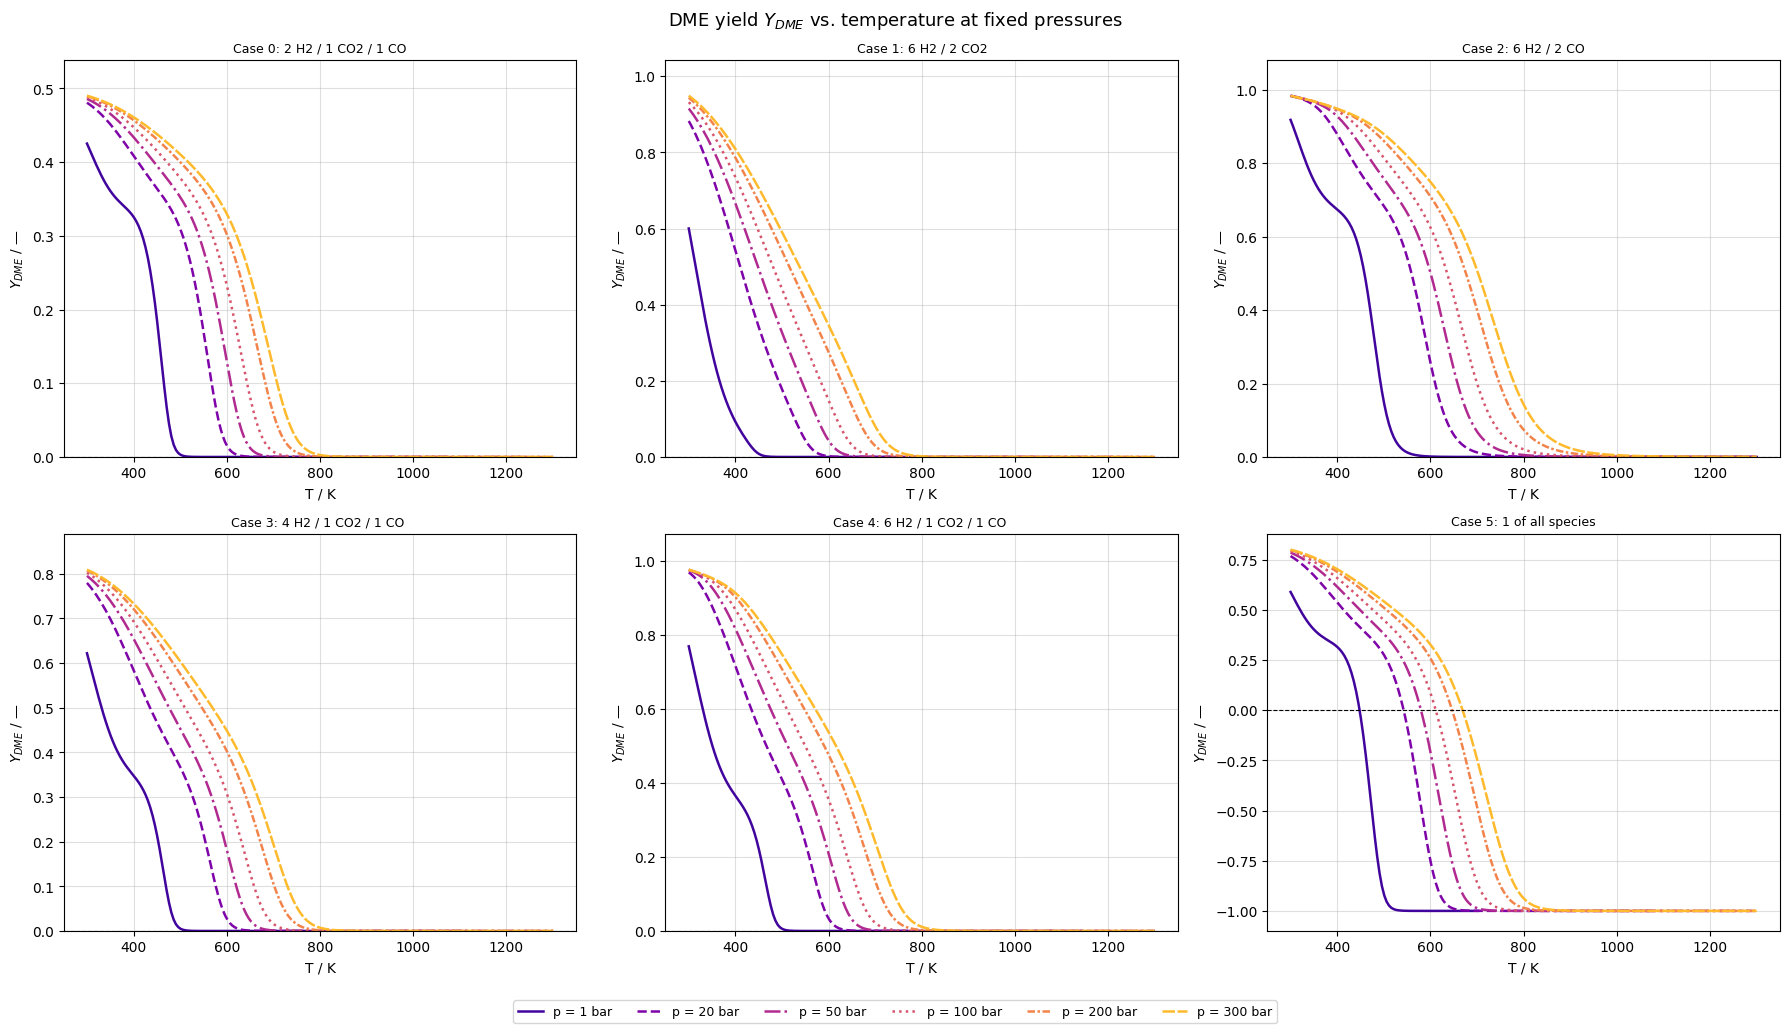

In [ ]:
# =============================================================================
# Y_DME vs T at fixed pressures — 2x3 subplot grid, one panel per test case
#
# Computed directly from the already calculated xi_2d array, so no additional
# solver calls are needed. The DME yield is calculated using the COx-normalised
# dme_yield() function defined earlier.
# =============================================================================

# --- Compute Y_DME for all cases and pressures from existing xi_2d ---
# Shape: (n_cases, n_pressures, n_temperatures)
Y_DME_2d = np.full((len(test_cases), len(pressures_2d), len(T_range_2d)), np.nan)

for ci, (name, n_in) in enumerate(test_cases):
    for pi, p in enumerate(pressures_2d):
        for ti in range(len(T_range_2d)):
            xi = xi_2d[ci, pi, :, ti]
            if np.any(np.isnan(xi)):
                continue
            n_out = material_balance(reaction_tuples, xi, n_in, reaction_indices)
            Y_DME_2d[ci, pi, ti] = dme_yield(n_in, n_out)

# --- Plotting: 2 rows x 3 cols grid, one subplot per test case ---
n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for ci, (name, n_in) in enumerate(test_cases):
    ax = axes[ci]

    for pi, p in enumerate(pressures_2d):
        ax.plot(
            T_range_2d,
            Y_DME_2d[ci, pi, :],
            color=p_colors_2d[pi],
            linestyle=p_linestyles_2d[pi],
            linewidth=1.8,
            label=f'p = {p} bar'
        )

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('T / K', fontsize=10)
    ax.set_ylabel(r'$Y_{DME}$ / —', fontsize=10)
    ax.set_title(name, fontsize=9)
    ax.grid(True, alpha=0.4)

    # Set y-axis limits individually per case to ensure all values are visible
    y_max = np.nanmax(Y_DME_2d[ci, :, :])
    y_min = np.nanmin(Y_DME_2d[ci, :, :])
    # Use 0 as lower bound unless negative values are present
    ax.set_ylim(min(0, y_min * 1.1), y_max * 1.1)

# Hide unused subplots if n_cases < 6
for ci in range(len(test_cases), n_rows * n_cols):
    axes[ci].set_visible(False)

# Shared legend at the bottom, horizontal layout
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center', bbox_to_anchor=(0.5, -0.04),
    ncol=len(pressures_2d), fontsize=9, frameon=True
)

fig.suptitle(r'DME yield $Y_{DME}$ vs. temperature at fixed pressures', fontsize=13)
plt.tight_layout()
plt.show()

The DME yield $Y_{DME}$ plotted across all six cases closely mirrors the reaction extent $\xi$ of R4 shown above, which is expected since $Y_{DME}$ is directly calculated from the equilibrium outlet composition via the stoichiometric yield definition (Eq. 4). All trends discussed for R4 — the pressure dependence, the temperature window of spontaneous DME formation, the effect of feed composition, and the convergence at high temperatures — therefore carry over directly to the yield plots, confirming the internal consistency of the simulation.

The maximum achievable $Y_{DME}$ differs significantly between cases. Cases 1 and 2, which contain only a single carbon oxide species, reach the highest yields of approximately 1.0 at low temperatures and high pressures, since all available $\mathrm{CO}_x$ is directed into a single methanol synthesis pathway. Cases 3 and 4, with higher $\mathrm{H}_2$/$\mathrm{CO}_x$ ratios, also approach yields close to 1.0 at 300 bar, while Case 0 with the lowest $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio of 1 is limited to a maximum yield of approximately 0.5, reflecting the $\mathrm{H}_2$-limited methanol synthesis discussed above. Case 5 shows negative yields at high temperatures, consistent with the reverse of R4 consuming DME already present in the feed, as discussed in Section 5.1.

Notably, the yield curves exhibit a sharper temperature dependence at lower pressures, meaning the transition from high to zero yield occurs over a narrower temperature window at 1 bar compared to 300 bar. This has practical implications for reactor design: operating at high pressure not only increases the maximum equilibrium yield but also broadens the temperature window within which meaningful DME production is thermodynamically feasible, providing greater flexibility in reactor operation.

# 7. Discussion of Results

The stoichiometric network analysis confirmed a system rank of $R_N = 3$, identifying three linearly independent key reactions. By partitioning the stoichiometric matrix $\underline{N}$ into key and non-key submatrices, numerical stability of the equilibrium solver was ensured through the invertibility of the core submatrix $\underline{N}_{11}$. The thermodynamic foundation of the model, grounded in NASA-Glenn polynomial coefficients, was validated against NIST-JANAF reference data at 298.15 K, 500 K and 1000 K, showing excellent agreement across all species. The equilibrium constants calculated from our model show a systematic offset relative to the empirically refitted values of Graaf & Winkelman [4], which was shown to originate not from an error in our implementation but from the known sensitivity of the exponential $K^\circ$ relation to small differences in the thermodynamic baseline data — specifically the deliberate refitting of methanol formation energies in [4] to match high-pressure experimental data.

The analysis of the reaction extents and DME yield across all cases consistently confirms the following thermodynamic trends. Both methanol synthesis reactions R1 and R2,

\begin{equation}
    \mathrm{CO}_2 + 3\,\mathrm{H}_2 \rightleftharpoons \mathrm{CH}_3\mathrm{OH} + \mathrm{H}_2\mathrm{O} \tag{26}
\end{equation}

\begin{equation}
    \mathrm{CO} + 2\,\mathrm{H}_2 \rightleftharpoons \mathrm{CH}_3\mathrm{OH} \tag{27}
\end{equation}

are exothermic and proceed with a reduction in the total number of moles ($\Delta\nu = -2$ for both). As a consequence, the equilibrium is shifted toward products at low temperatures and high pressures in accordance with Le Chatelier's principle. Above approximately 800–1000 K — depending on pressure — both reactions become thermodynamically unfavorable, the methanol supply to the dehydration step R4 is cut off, and the DME yield drops sharply to zero. R4 itself,

\begin{equation}
    2\,\mathrm{CH}_3\mathrm{OH} \rightleftharpoons \mathrm{CH}_3\mathrm{OCH}_3 + \mathrm{H}_2\mathrm{O} \tag{28}
\end{equation}

carries no intrinsic pressure dependence since $\Delta\nu_{R4} = 0$, but is indirectly controlled by the methanol availability established by R1 and R2. The pressure dependence of the overall DME yield therefore originates entirely from R1 and R2, even though R4 is the terminal DME-forming step.

The feed composition has a strong influence on the maximum achievable yield. A pure $\mathrm{CO}$ feed (Case 2) consistently outperforms a pure $\mathrm{CO}_2$ feed (Case 1) at the same temperature and pressure, reaching higher DME yields due to the lower water co-production of R2 compared to R1, which reduces inhibition of the dehydration equilibrium. Mixed $\mathrm{CO}$/$\mathrm{CO}_2$ feeds (Cases 0, 3, 4) show intermediate behavior, with the $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio playing a decisive role: at ratios below approximately 3, $\mathrm{H}_2$ availability limits R1, which runs in reverse and consumes methanol formed by R2, reducing the DME yield. Above a ratio of approximately 3, both R1 and R2 reach near-complete conversion and the DME yield plateaus, meaning further increases in $\mathrm{H}_2$ feed no longer improve process performance. The stoichiometric optimum for a mixed $\mathrm{CO}$/$\mathrm{CO}_2$ feed is therefore a $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio of approximately 3, which corresponds to the combined stoichiometric demand of R1 and R2:

\begin{equation}
    \frac{\mathrm{H}_2}{\mathrm{CO}_x} = \frac{\nu_{\mathrm{H}_2,R1} \cdot \dot{n}_{\mathrm{CO}_2,in} + \nu_{\mathrm{H}_2,R2} \cdot \dot{n}_{\mathrm{CO},in}}{\dot{n}_{\mathrm{CO}_2,in} + \dot{n}_{\mathrm{CO},in}} = \frac{3 + 2}{2} = 2.5 \approx 3 \tag{29}
\end{equation}

Comparing our results with Ng et al. [7], who report DME yields between 10% and 20% for $\mathrm{H}_2$/$\mathrm{CO}_x$ ratios between 1 and 4, our simulation gives yields in a broadly similar range. The results are qualitatively consistent in that higher $\mathrm{H}_2$/$\mathrm{CO}_x$ ratios lead to higher DME yields, but a quantitative offset is observed. This discrepancy likely originates from differences in the assumed feed composition: Ng et al. do not specify the $\mathrm{CO}$/$\mathrm{CO}_2$ split within $\mathrm{CO}_x$, whereas our simulation uses a pure $\mathrm{CO}_2$ feed for the comparable cases, which — as shown above — yields lower DME than a $\mathrm{CO}$-containing feed at the same $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio. Additionally, the conditions reported by Ng et al. differ from ours in temperature and pressure, which further limits direct quantitative comparability.

From the combined thermodynamic analysis, the optimal operating window for DME synthesis from syngas can be identified as follows: low to intermediate temperatures (300–550 K), high pressures (100–300 bar), and a $\mathrm{H}_2$/$\mathrm{CO}_x$ ratio of approximately 3, ideally with a $\mathrm{CO}$-rich feed to minimize water inhibition of R4. It must be noted, however, that this analysis is purely thermodynamic and does not account for reaction kinetics. In practice, excessively low temperatures reduce reaction rates significantly, and the thermodynamic optimum may therefore not be accessible without highly active catalysts. The actual operating point will require a tradeoff between thermodynamic yield and kinetic feasibility, and will depend on the specific catalyst and reactor design employed.

### 7.1. Link to Industry

Dimethyl ether (DME) can be used as an alternative to conventional diesel fuel [10] or LPG [11]. In practice, a thermodynamic equilibrium simulation of the kind presented here serves as a foundational tool in process development, since it establishes the thermodynamic upper bound on reactor performance before any kinetic or engineering constraints are considered. Operating the system at the temperature, pressure, and inlet composition that maximize the equilibrium DME yield defines the theoretical limit against which real reactor performance can be benchmarked. This is particularly valuable in the early stages of process development, where such calculations can guide the selection of operating windows for first laboratory experiments and pilot-scale studies.

The simulation also makes it possible to evaluate different syngas feed compositions that may be available from upstream processes, and to identify the best feed composition for a given set of operating conditions. For feeds with a higher $\mathrm{CO}_2$/$\mathrm{CO}$ ratio, it may be favorable to use catalysts with a lower acid function [10]. This is because a higher $\mathrm{CO}_2$ content leads to increased water production in the reactor via R1, and this water adsorbs on the active sites of the dehydration catalyst, blocking methanol access and thereby slowing down R4 [10]. The equilibrium model quantifies how strongly this shift in feed composition affects the theoretical yield, providing a rational basis for catalyst selection.

In the case of a varying feed composition during operation — for example when processing syngas from different feedstocks — the equilibrium calculation can be used to define a dynamic performance metric for a fixed catalyst:

\begin{equation}
    \eta = \frac{Y_{\mathrm{DME,\,measured}}}{Y_{\mathrm{DME,\,equilibrium}}(T, p, \mathrm{feed})} \tag{30}
\end{equation}

This dimensionless efficiency $\eta$ expresses how closely the actual reactor approaches the thermodynamic limit under the prevailing conditions, and can serve as a basis for comparing catalyst performance across different operating scenarios.

On the industrial scale, a fixed-bed adiabatic reactor is a commonly used configuration for DME synthesis [10]. In such a reactor, the temperature rises along the reactor axis as the exothermic reactions proceed, which continuously shifts the local equilibrium composition. Since the equilibrium yield decreases with increasing temperature, as shown throughout this study, the temperature rise in an adiabatic reactor inherently limits the achievable conversion. This makes temperature management a central challenge in industrial reactor design, and illustrates why the thermodynamic landscape mapped in this study is directly relevant to practical reactor engineering.

It should be noted that this model cannot predict the performance of specific reactor types, account for heat management strategies, or describe reaction kinetics. These aspects — including the tradeoff between thermodynamic yield and reaction rate discussed above — would require a full kinetic model and reactor simulation, which lies beyond the scope of this thermodynamic equilibrium analysis.

# 8. AI Use and Reflection

1. **Tools used**: Google Gemini, Claude (Anthropic), May 2026.
2. **Areas of use**: Code generation for thermodynamic equilibrium solvers, debugging numerical resolution errors, development of 3D surface visualization scripts, and language refinement of the scientific discussion.
3. **Prompting strategy**: AI tools were utilized primarily for technical troubleshooting and syntax optimization. The intellectual structure and the core logic of the thermodynamic model were developed independently. Prompts were designed to request assistance with specific coding challenges rather than generating the underlying engineering argumentation.
4. **Critical examination**: Every AI-generated output was manually audited. We performed rigorous plausibility checks, including resolution sensitivity analyses, to confirm that the observed non-linearities were physically inherent to the equilibrium system. All yield calculations were validated against standard literature data (NIST WebBook and NASA thermodynamic tables) to ensure consistency and stoichiometric accuracy.
5. **Statement of own contribution**: The intellectual structure of this report is entirely our independent work. This includes the formulation of the equilibrium conditions, the scientific interpretation of the results, and the derivation of engineering conclusions regarding reactor operation. All scientific reasoning and engineering judgments are our own.

# 9. References
[1] Prof. Dr.-Ing. Robert Güttel, CRT_3_assignment_2_26.ipynb, Ulm, 2026.

[2] NASA Glenn Research Center, "Coefficients for Calculating Thermodynamic Properties of Individual Species," NASA Technical Reports Server, 2026.

[3] Chase, M.W., Jr. (1998). *NIST-JANAF Thermochemical Tables*, 4th Ed.

[4] Graaf, G.H.; Winkelman, J.G.M. *Ind. Eng. Chem. Res.* 2016, 55, 5854–5864, DOI: 10.1021/acs.iecr.6b00815.

[5] Diep, B.T.; Wainwright, M.S. *J. Chem. Eng. Data* 1987, 32, 330–333, DOI: 10.1021/je00049a015.

[6] National Institute of Standards and Technology (NIST), "Thermophysical Properties of Fluid Systems," NIST Chemistry WebBook, SRD 69.

[7] Ng, K.L.; Chadwick, D.; Toseland, B.A. *Chem. Eng. Sci.* 1999, 54, 3587–3592, DOI: 10.1016/S0009-2509(98)00514-4.

[8] N. Lawes, I. E. Gow, L. R. Smith et al., Methanol synthesis from CO2 and H2 using supported Pd alloy catalysts, Faraday Discuss., 2023, 242, 193–211, https://doi.org/10.1039/D2FD00119E.

[9] Y. Kansha, M. Ishizuka, C. Song and A. Tsutsumi, Process intensification for dimethyl ether production by self-heat recuperation, Energy, 2015, 90, 122–127, https://doi.org/10.1016/j.energy.2015.05.037.

[10] Vakili, R.; Eslamloueyan, R.; Jahanmiri, A. Chem. Eng. Process. 2011,50, 85–94, DOI: 10.1016/j.cep.2010.11.003.

[11] International DME Association (IDA), "DME/LPG Blends," IDA Fact Sheet No. 1, 2010.